## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_standard_14"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [5]:
override = True
use_preds = False
save = True
show = True
scaler_name = "standard"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


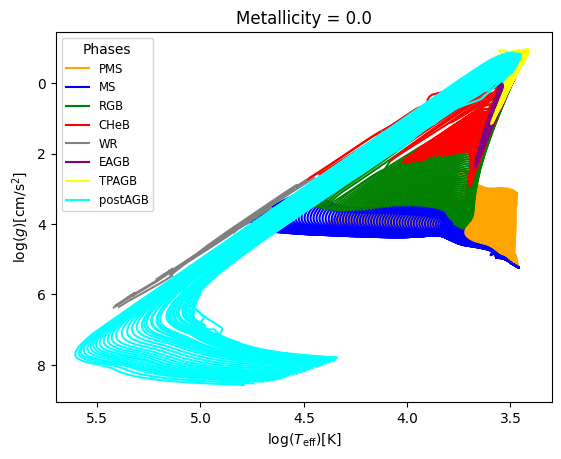

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.00,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.00,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.00,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.05,4.482577,4.350883,0.0,-0.25,12.925175,0.596074
4,5.05,4.485667,4.349692,0.0,-0.25,13.105490,0.600130
...,...,...,...,...,...,...,...
519286,10.30,3.602322,1.827453,3.0,0.50,0.866616,1.274247
519287,10.30,3.600999,1.809405,3.0,0.50,0.866614,1.283270
519288,10.30,3.599710,1.791489,3.0,0.50,0.866612,1.292228
519289,10.30,3.598418,1.773621,3.0,0.50,0.866610,1.301161


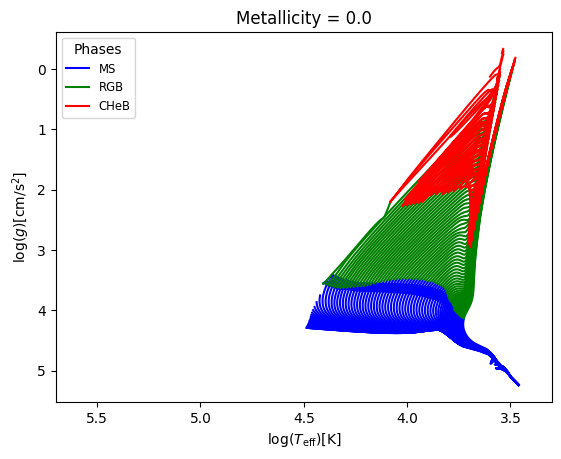

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], 'star_mass':('<', 14)})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.4629, Median : 8.5

log_Teff  : Range : 3.34 - 4.6345, Mean : 3.9346, Median : 3.8644

log_g  : Range : -1.08 - 5.4331, Mean : 3.5485, Median : 3.9492

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 13.9995, Mean : 3.398, Median : 2.0471

log_R  : Range : -1.0 - 3.0828, Mean : 0.6067, Median : 0.5386



In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 13.998624815474695
Median value in train data for the star_mass parameter: 2.0464342686349397
Mean value in train data for the star_mass parameter: 3.3973846370701644

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981896729906 - 13.99946885003588
Median value in test data for the star_mass parameter: 2.048860774010381
Mean value in test data for the star_mass parameter: 3.399812923045874

Range in test data for the log_R parameter : -0.9974234436680278 - 3.0827540579576227
Median value in test data for the log_R parameter: 0.5398730026691951
Mean value in test data for the log_R parameter: 0.6057854356870224

(389468, 4) (129823, 4)
(38

## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.7035807035771336
  RMSE :  1.7944310575952442
  MAE :  1.4533067736505072
  MedAE :  1.2390292764149775
  CORR :  0.8532020075802782
  MAX_ER :  7.719467844928937
  Percentiles : 
    75th percentile :  2.0590640249931207
    90th percentile :  2.825598975577787
    95th percentile :  3.3158861311333965
    99th percentile :  4.983118233497102

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.7627584839179392
  RMSE :  1.5838867857755048
  MAE :  1.0715385149714436
  MedAE :  0.7504074523788966
  CORR :  0.918408158140721
  MAX_ER :  7.092367586463594
  Percentiles : 
    75th percentile :  1.1937892073384093
    90th percentile :  2.321949633802384
    95th percentile :  4.0199602099

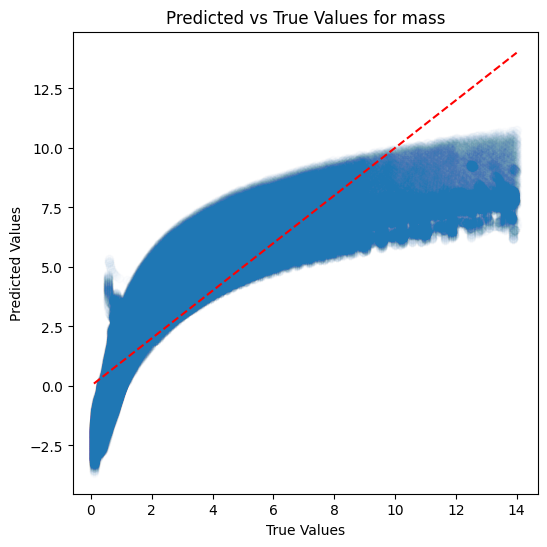

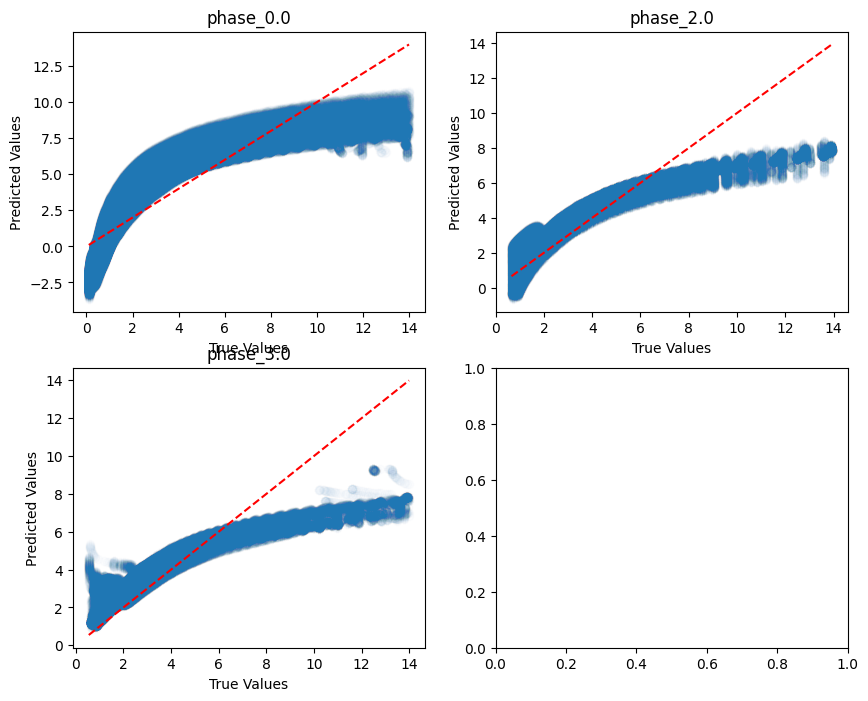

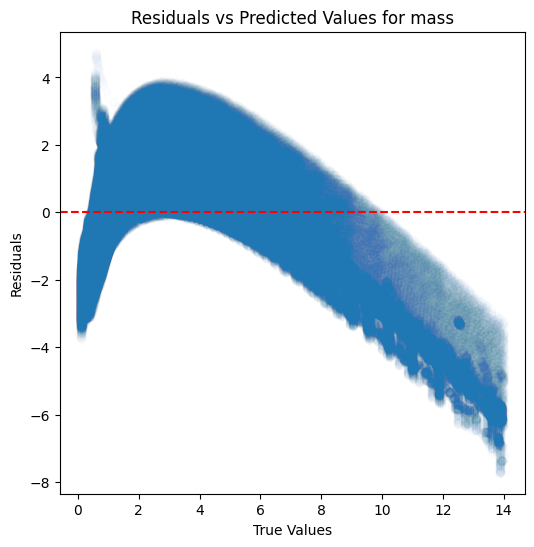

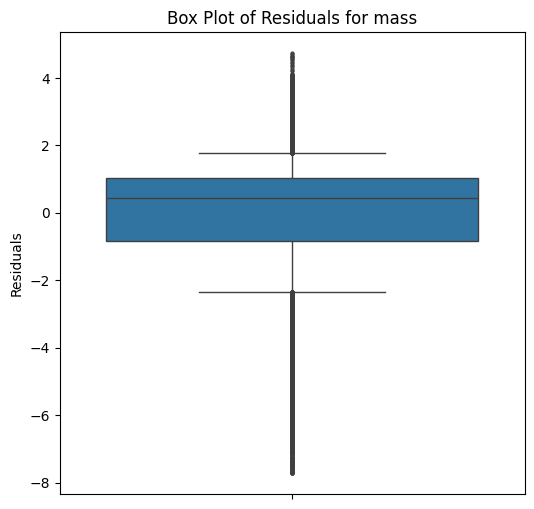

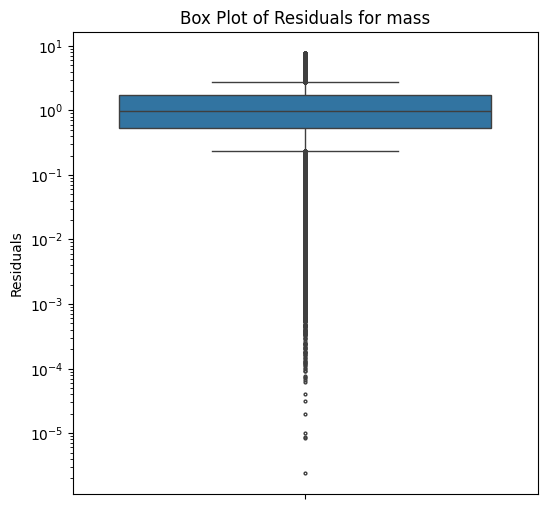

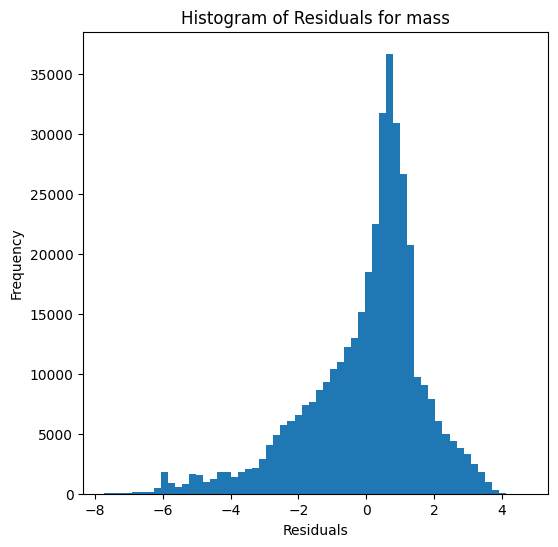

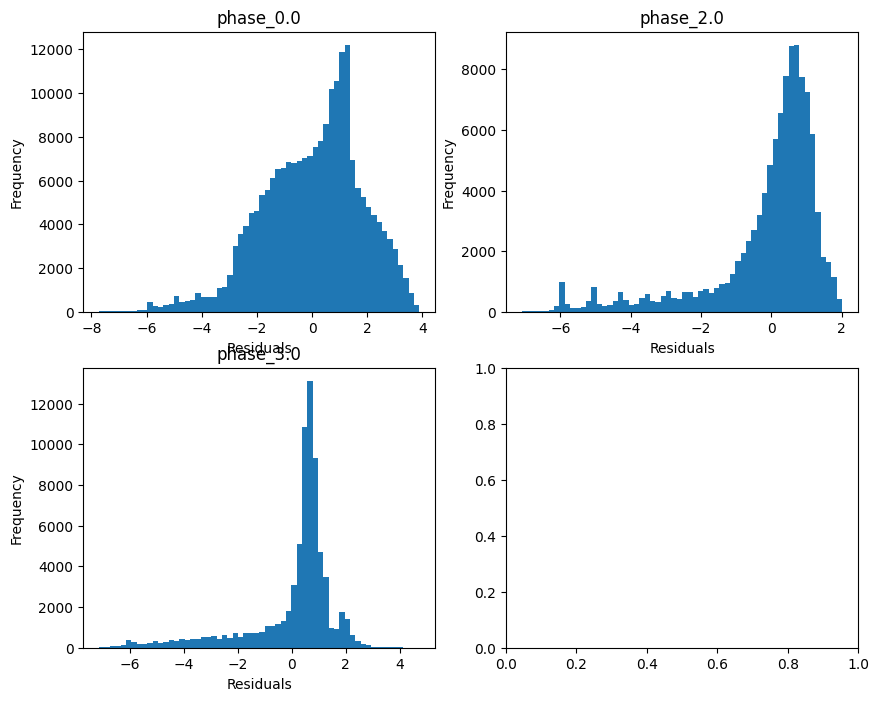

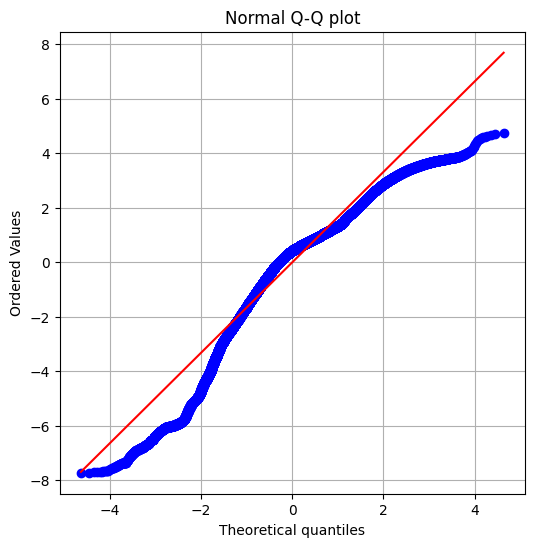

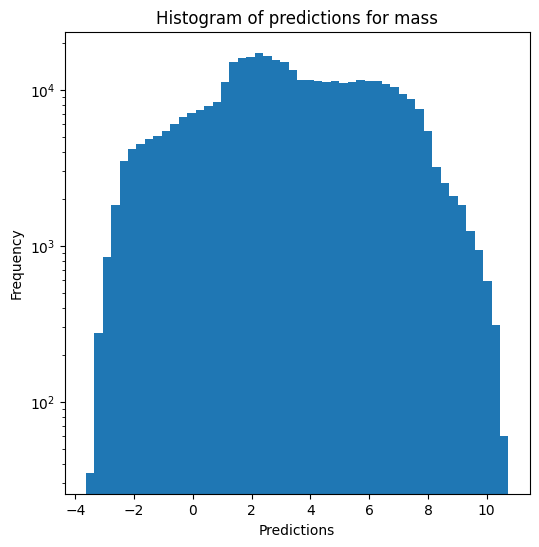

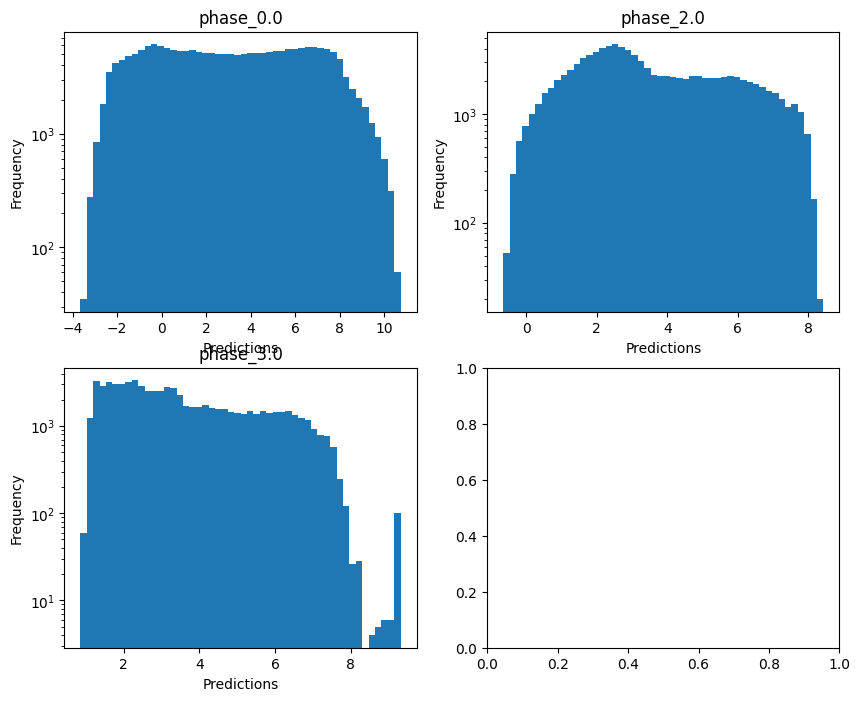

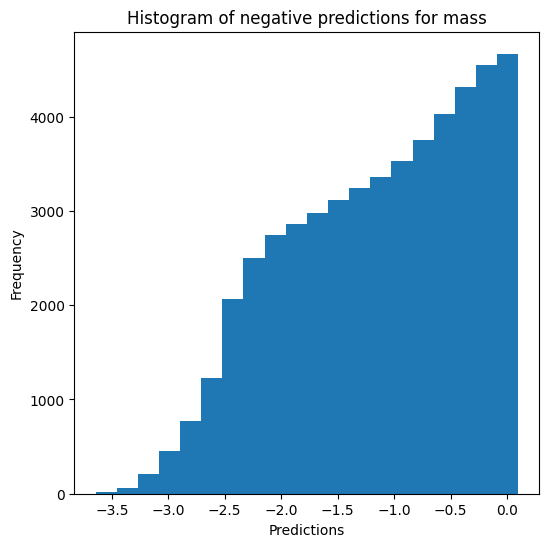


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9830496323087857
  RMSE :  0.05520328535718826
  MAE :  0.04232385004842921
  MedAE :  0.03380761139012295
  CORR :  0.9914885941715925
  MAX_ER :  0.21950730766513038
  Percentiles : 
    75th percentile :  0.06358314910867657
    90th percentile :  0.09183151165955747
    95th percentile :  0.10867394268203111
    99th percentile :  0.15558805272502638

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9806856109752657
  RMSE :  0.06618133063179639
  MAE :  0.05156292525842197
  MedAE :  0.04193665494450194
  CORR :  0.990979790460051
  MAX_ER :  0.24910103749835733
  Percentiles : 
    75th percentile :  0.07266590465907502
    90th percentile :  0.10861353273074642
    95th percentile :  0.13449970493125282
    99th percentile :  0.18544938117127396

radius results for the phase cat

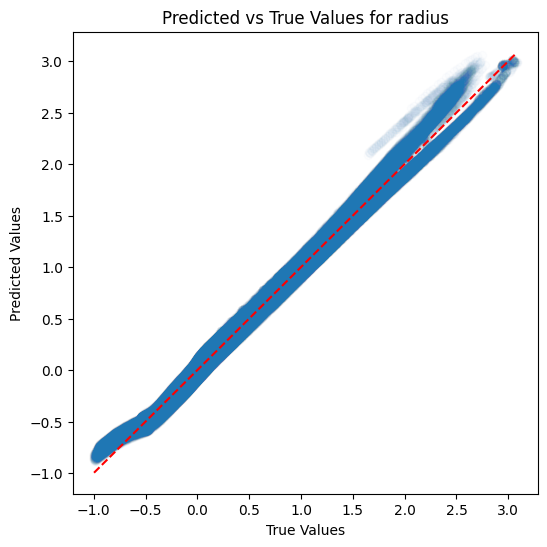

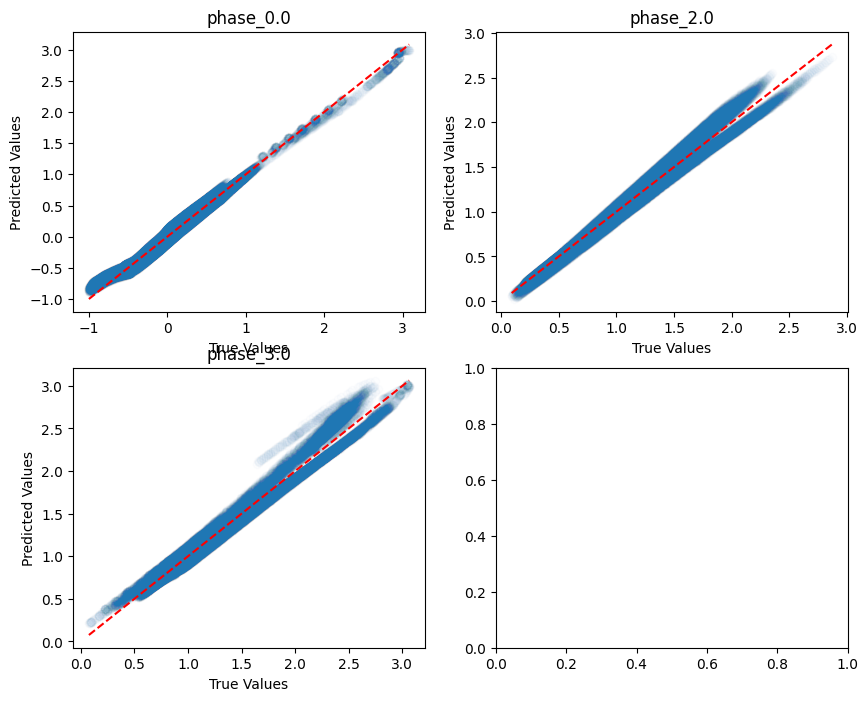

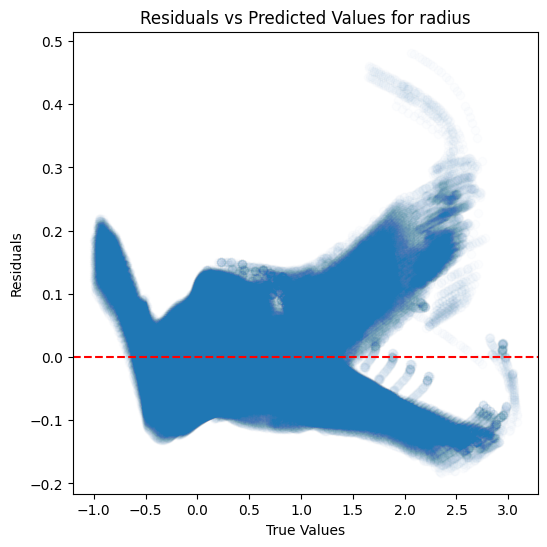

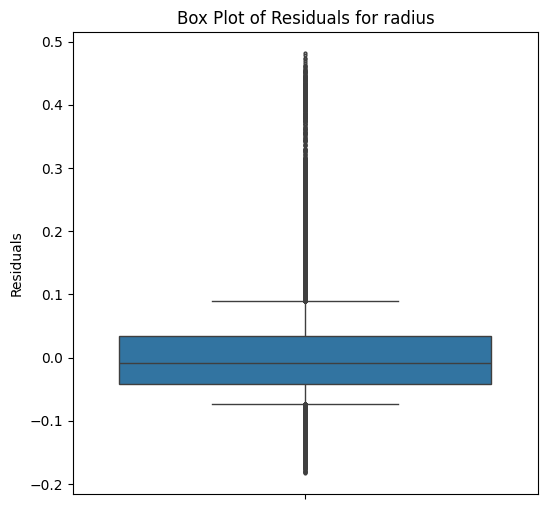

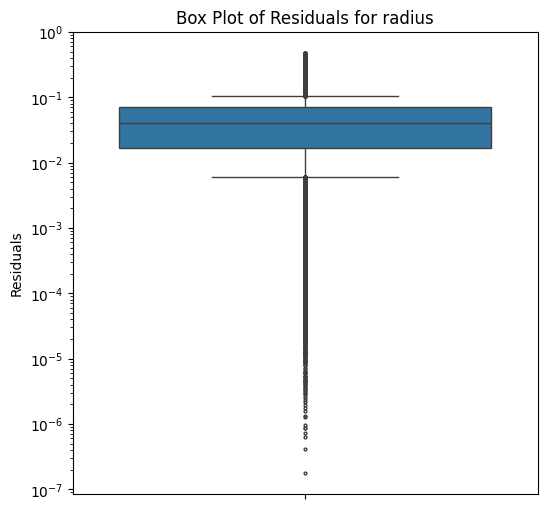

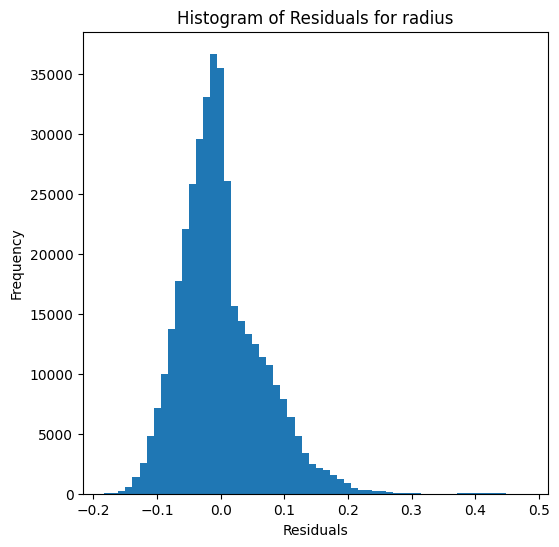

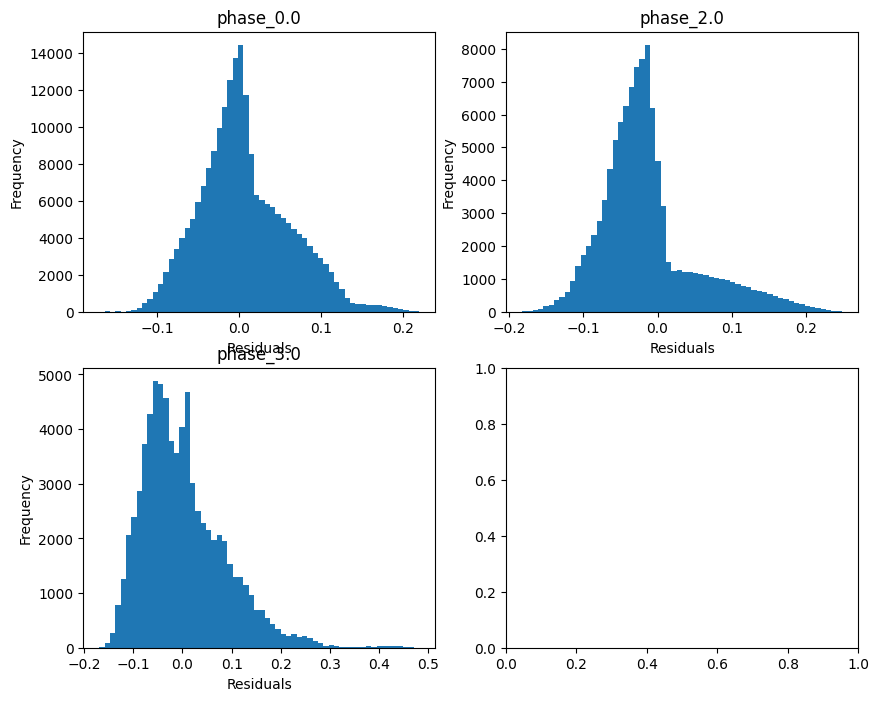

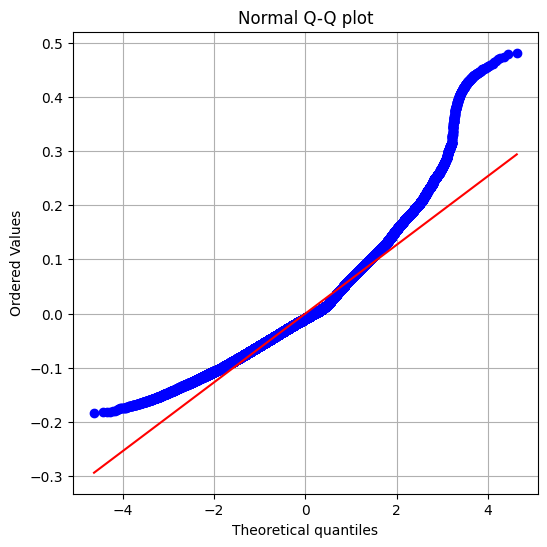

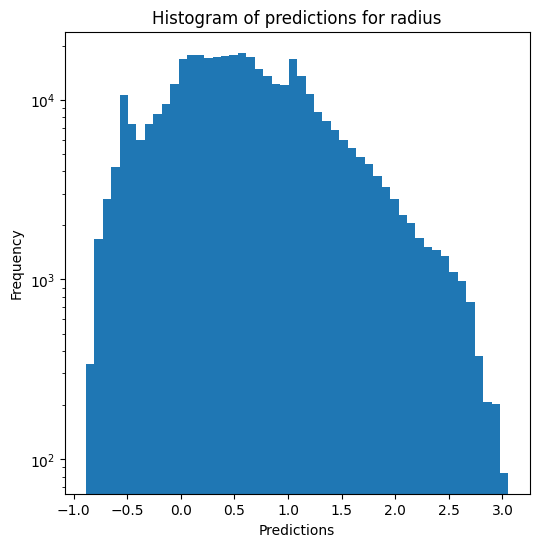

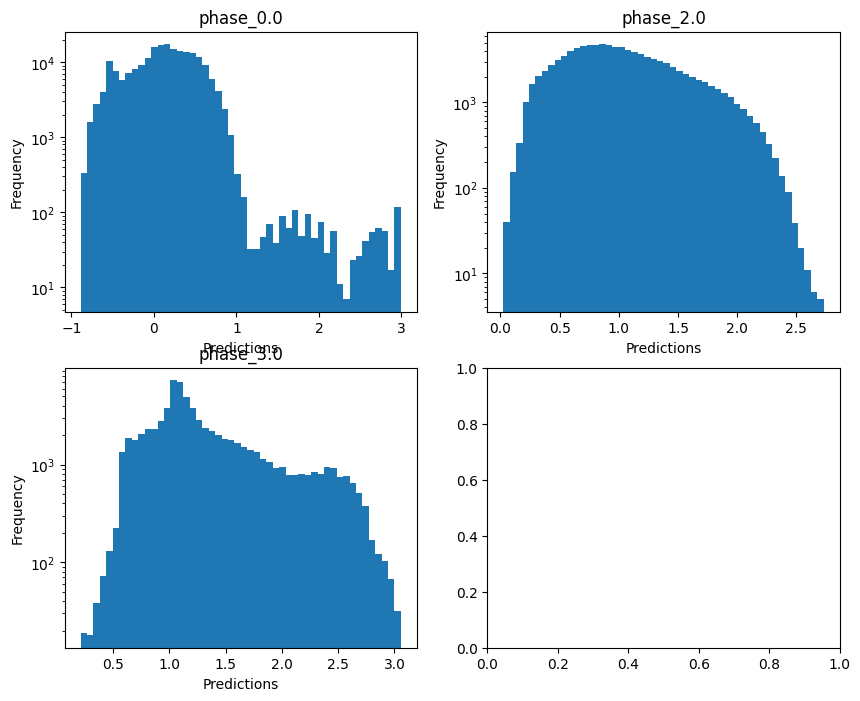

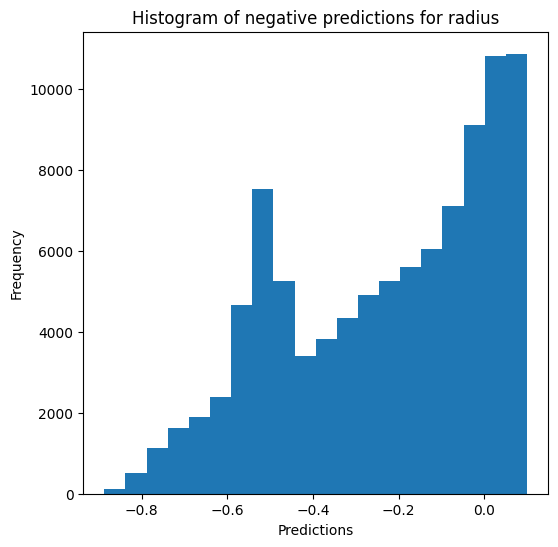

Saving predictions and results...


In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997530617047778
  RMSE :  0.051786013459192946
  MAE :  0.017001515112152272
  MedAE :  0.004131390227302356
  CORR :  0.9998765259740009
  MAX_ER :  5.054212555120426
  Percentiles : 
    75th percentile :  0.013667227696978923
    90th percentile :  0.042057948908400554
    95th percentile :  0.07414055101828186
    99th percentile :  0.19527535312908875

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999405593642136
  RMSE :  0.025053659585101855
  MAE :  0.007696223190502424
  MedAE :  0.0003243218757602584
  CORR :  0.9999704066139526
  MAX_ER :  1.4112652929022005
  Percentiles : 
    75th percentile :  0.0058006073577502315
    90th percentile :  0.023464336395521715
    95

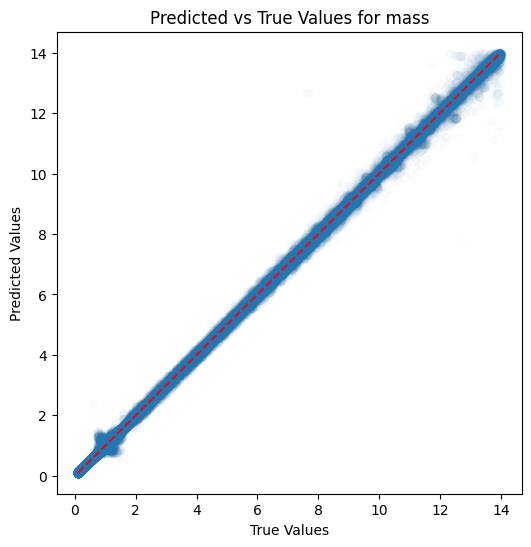

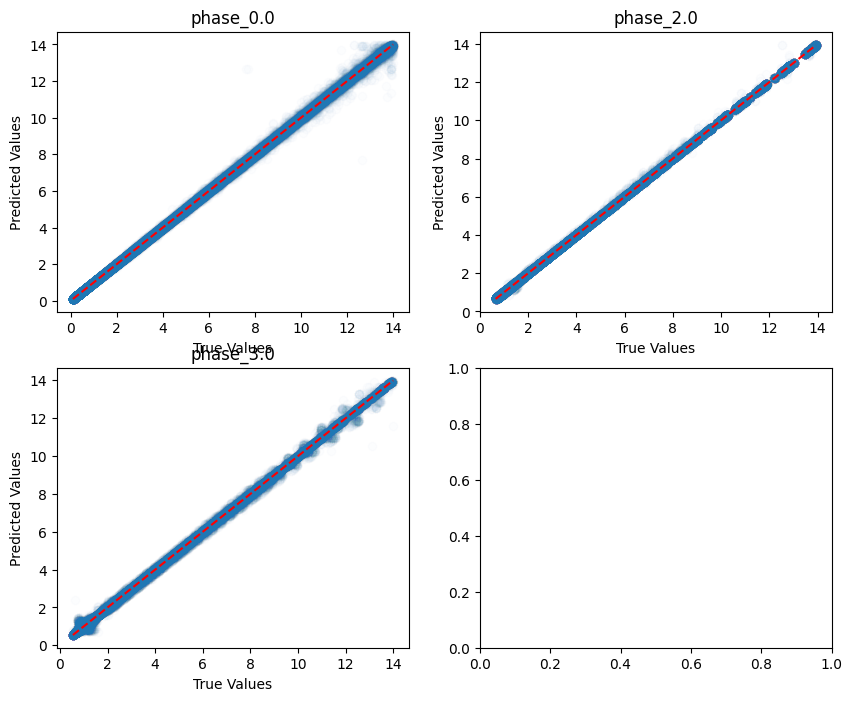

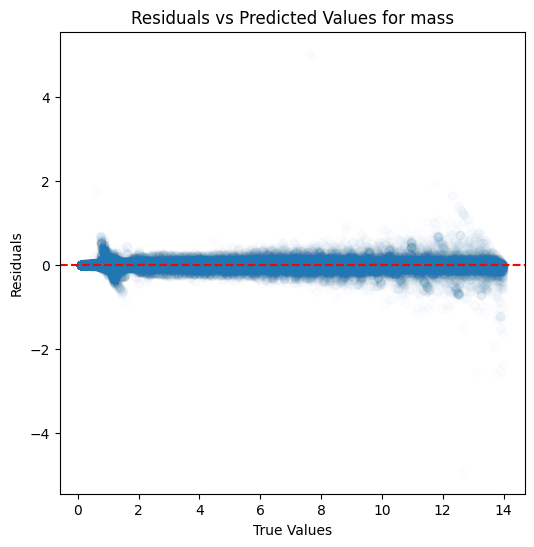

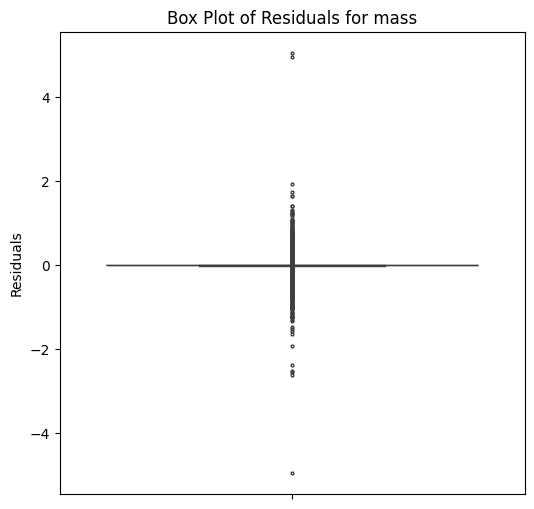

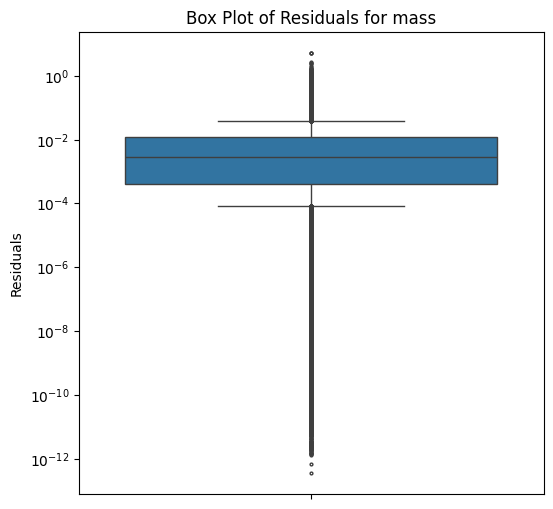

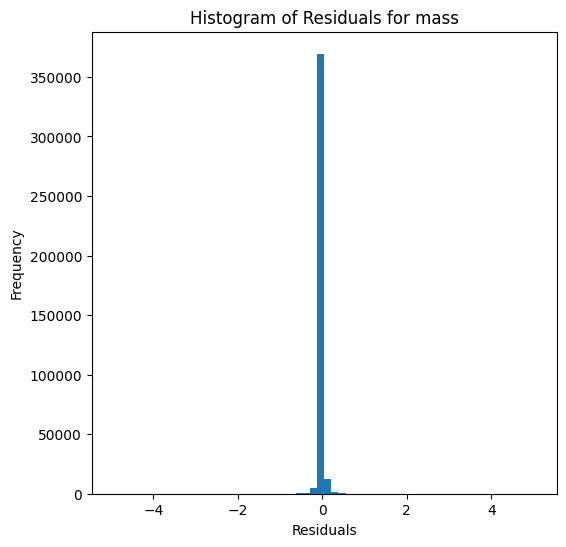

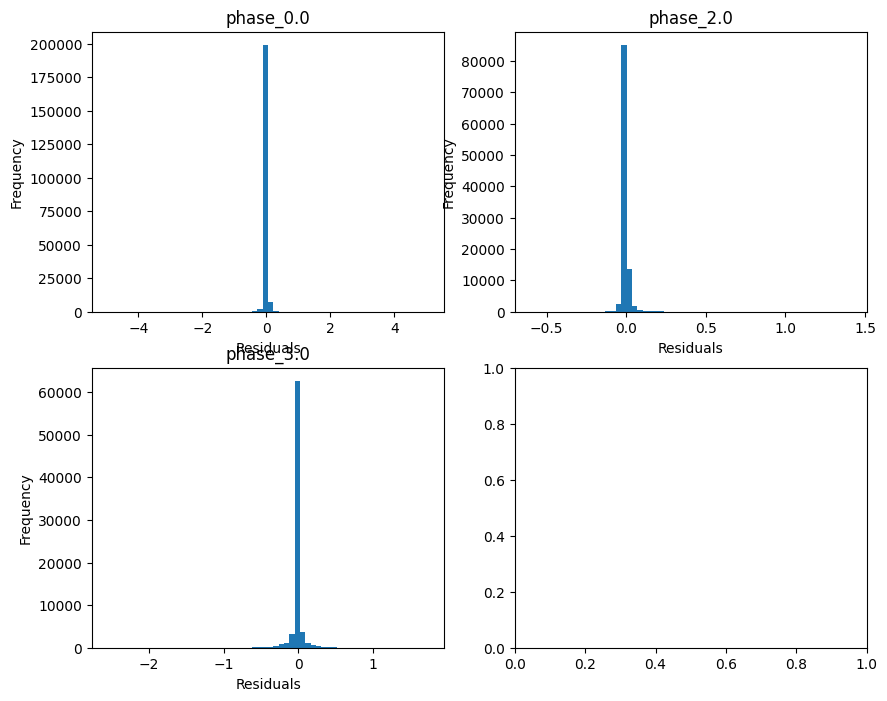

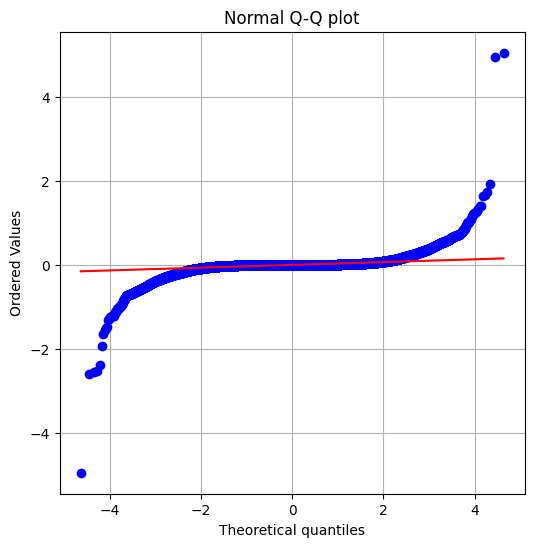

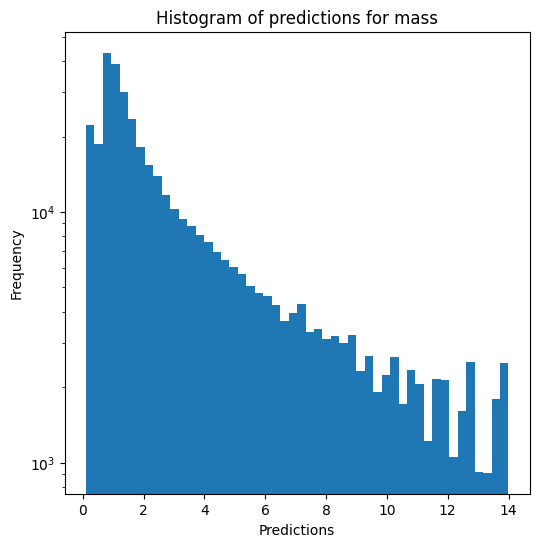

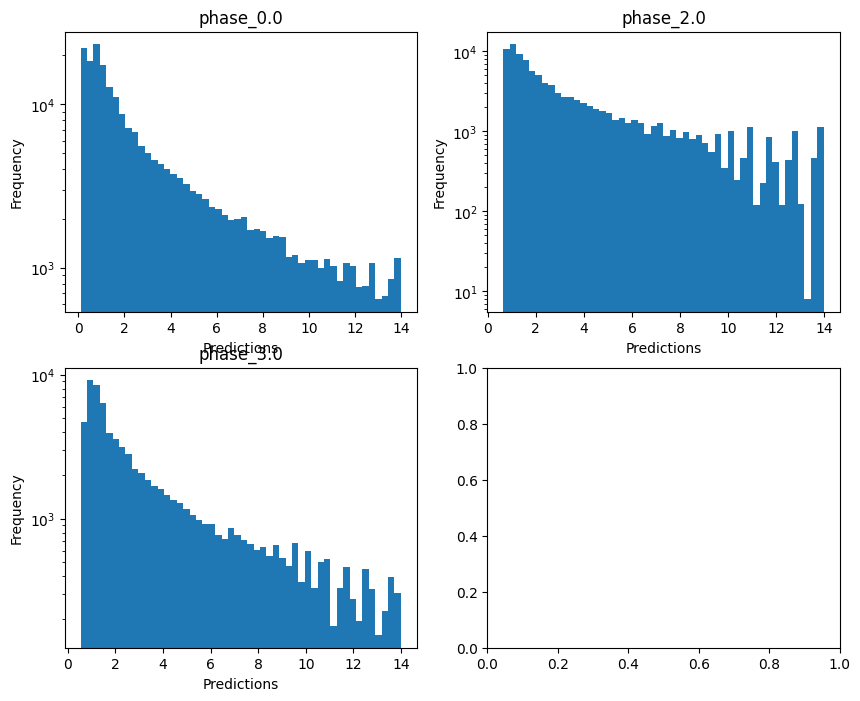

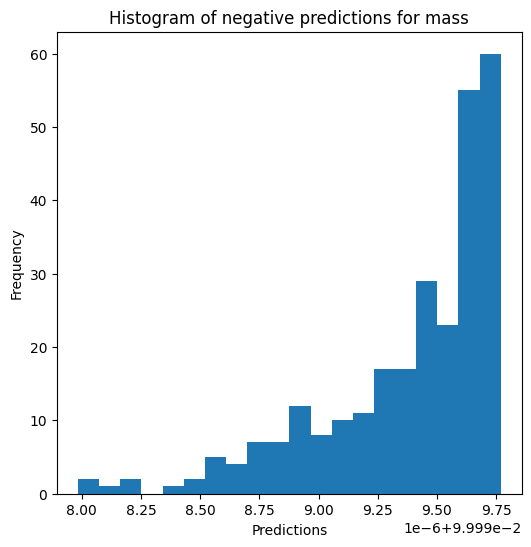


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9997893014425546
  RMSE :  0.006118842570584661
  MAE :  0.003633068082406072
  MedAE :  0.002289306993454393
  CORR :  0.9998946486087024
  MAX_ER :  0.3111731559611798
  Percentiles : 
    75th percentile :  0.004562556505883775
    90th percentile :  0.008046269109258233
    95th percentile :  0.01127249527713455
    99th percentile :  0.023813996315174543

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9994989055092656
  RMSE :  0.010428355001299603
  MAE :  0.007341524876387611
  MedAE :  0.006031807498511871
  CORR :  0.9997514423600432
  MAX_ER :  0.445657670892194
  Percentiles : 
    75th percentile :  0.009818116547751568
    90th percentile :  0.013858821827136193
    95th percentile :  0.0173141145059088
    99th percentile :  0.03196103477707671

radius results for the p

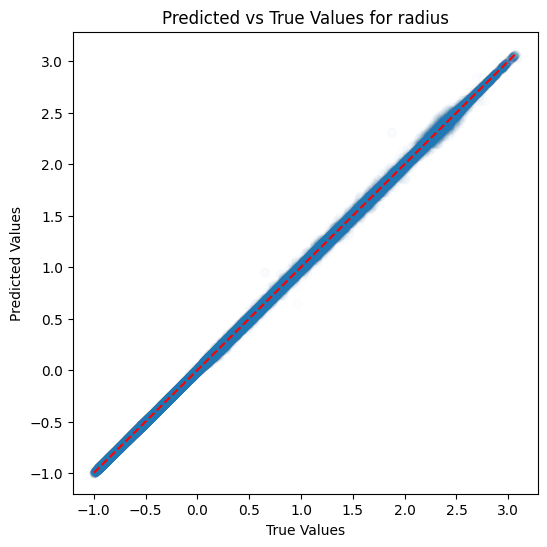

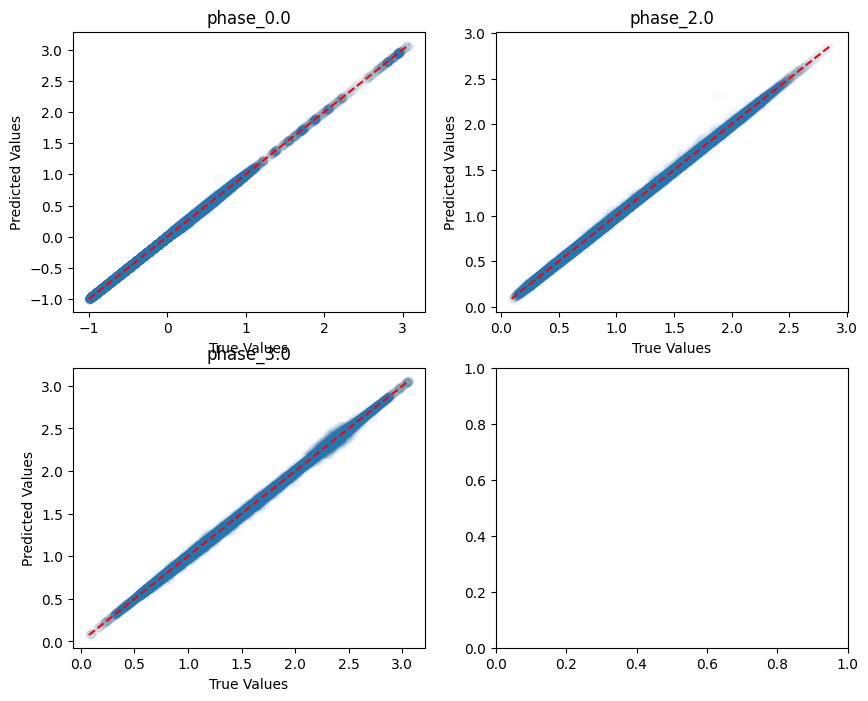

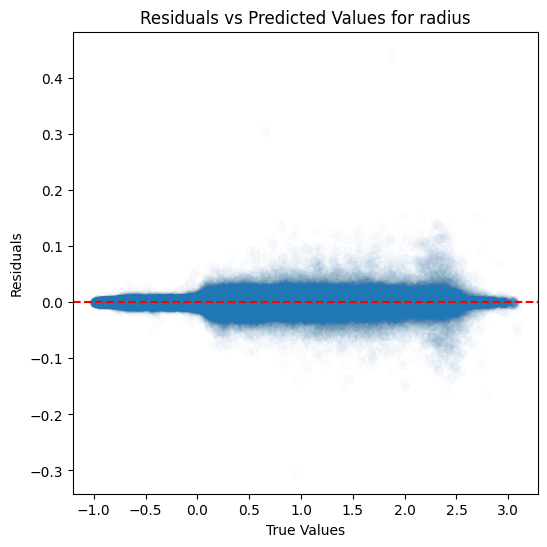

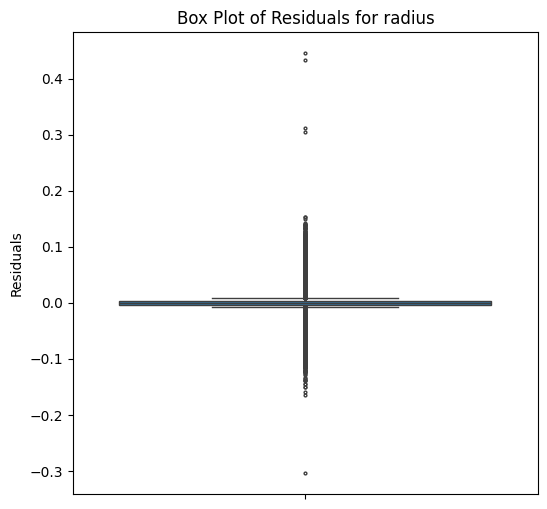

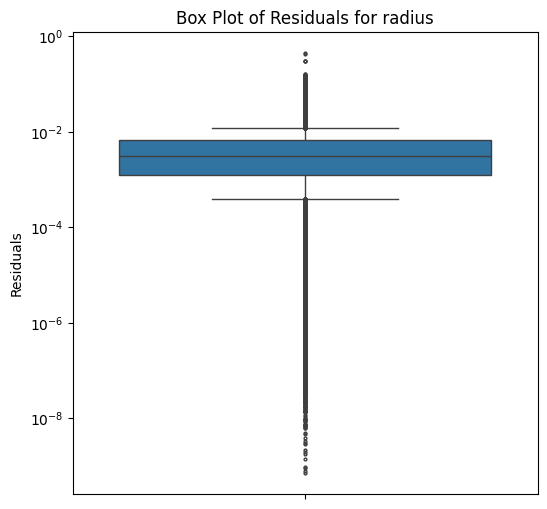

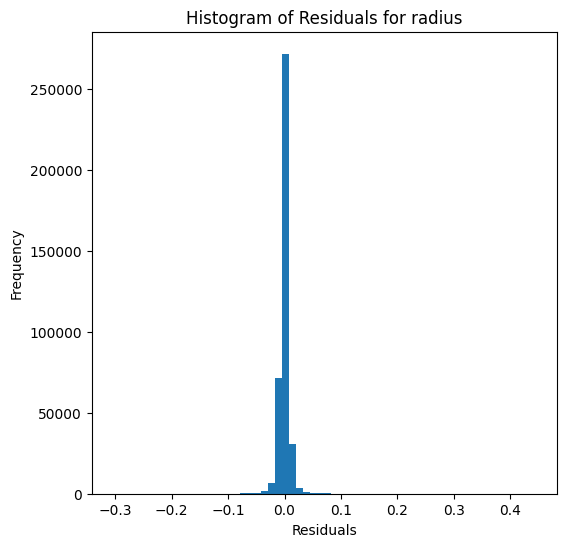

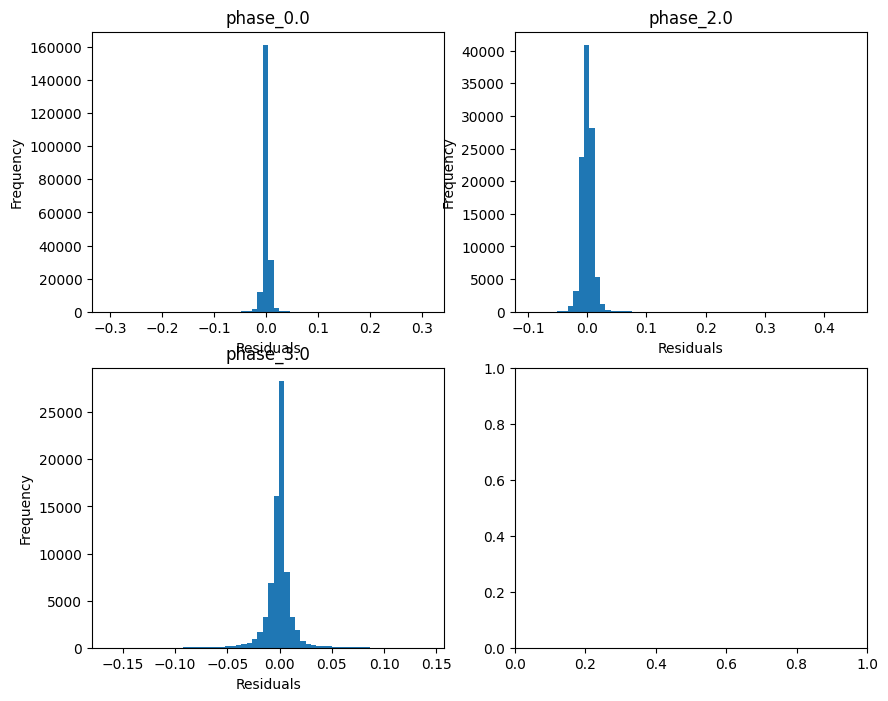

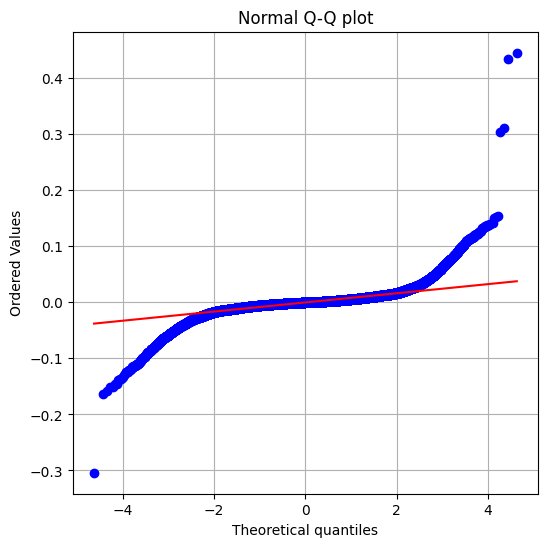

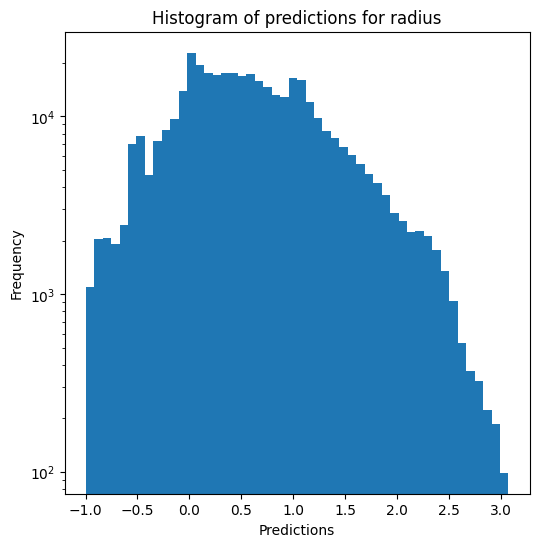

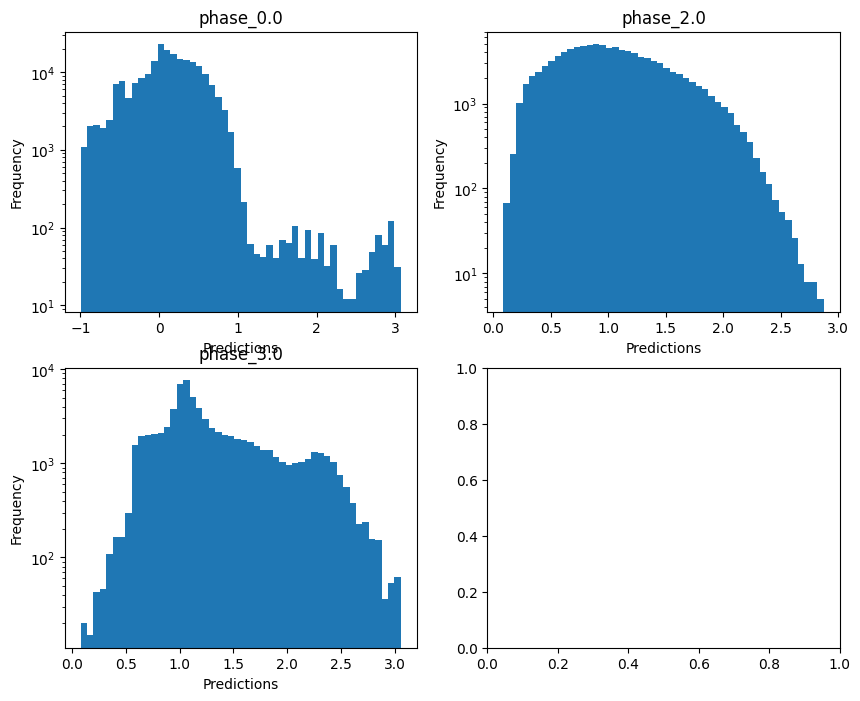

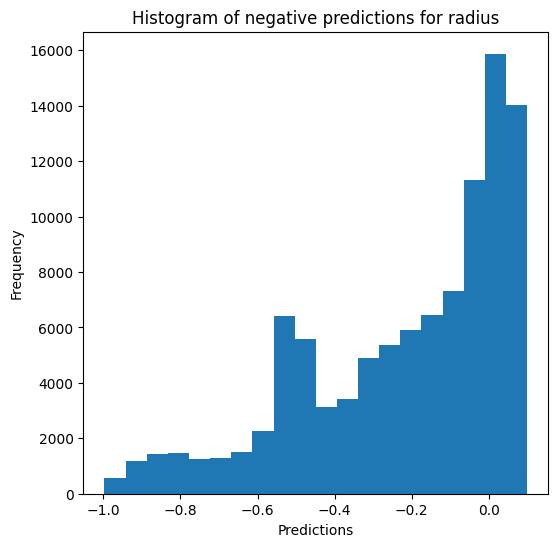

Saving predictions and results...


In [13]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997836923040405
  RMSE :  0.04847051855837037
  MAE :  0.018551840722279993
  MedAE :  0.004858514172388473
  CORR :  0.9998926089248183
  MAX_ER :  2.6133555400552364
  Percentiles : 
    75th percentile :  0.015763240167798287
    90th percentile :  0.04766588564989542
    95th percentile :  0.08453344007740748
    99th percentile :  0.19453847148292364

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997355564817435
  RMSE :  0.052837873462207086
  MAE :  0.020272086940226076
  MedAE :  0.004825651957223842
  CORR :  0.9998692513320424
  MAX_ER :  0.984844261976372
  Percentiles : 
    75th percentile :  0.014947480301168325
    90th percentile :  0.0565739482

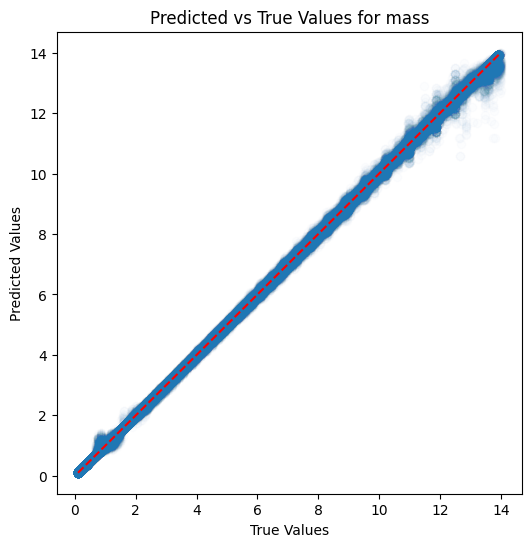

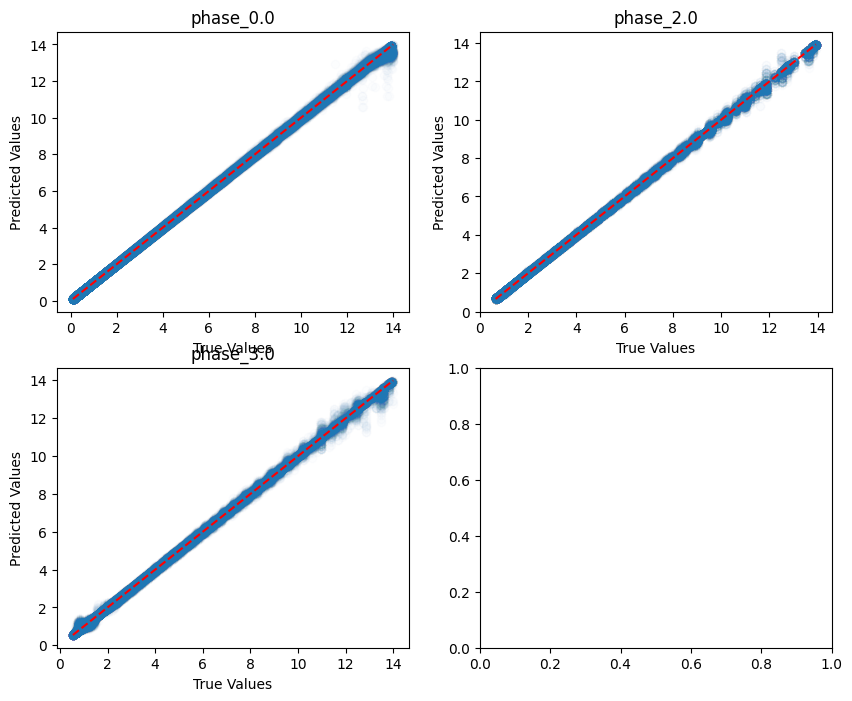

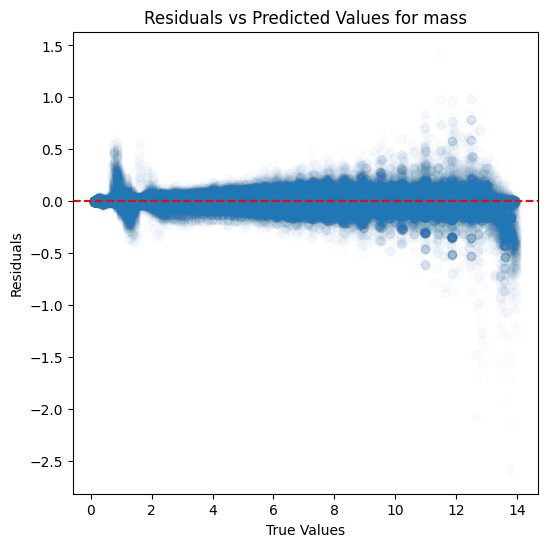

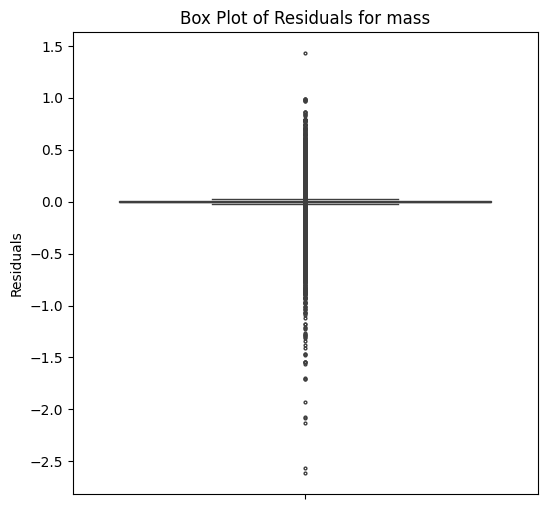

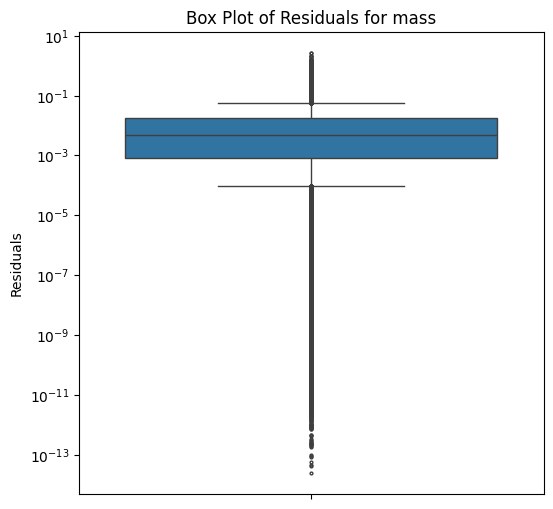

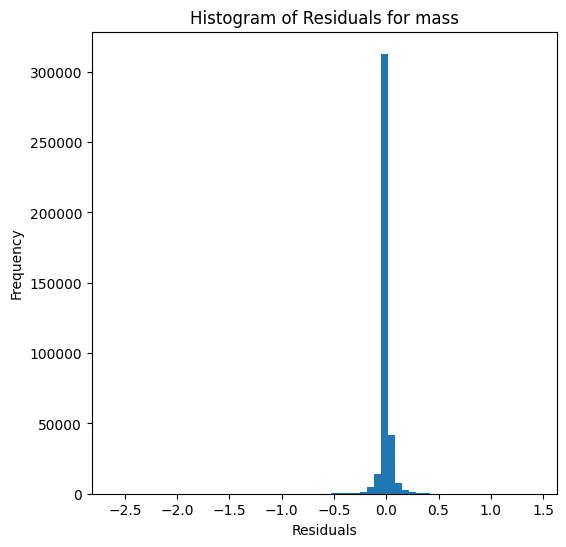

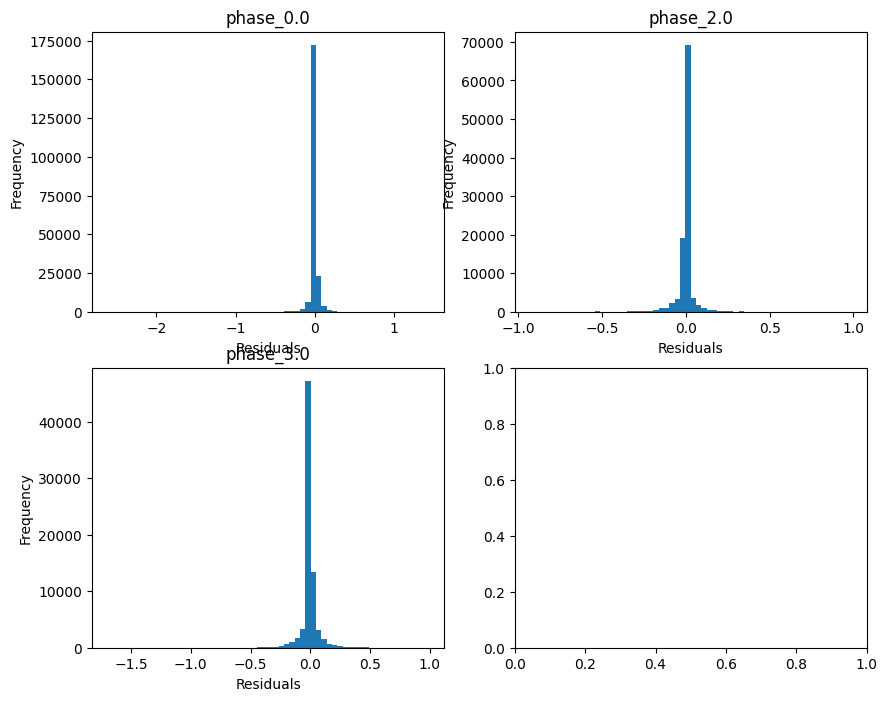

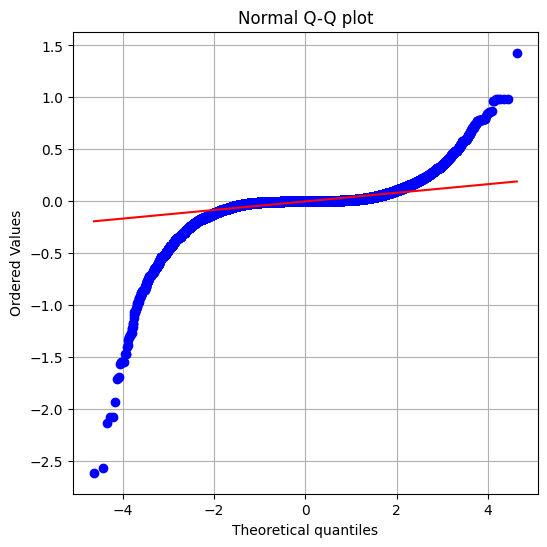

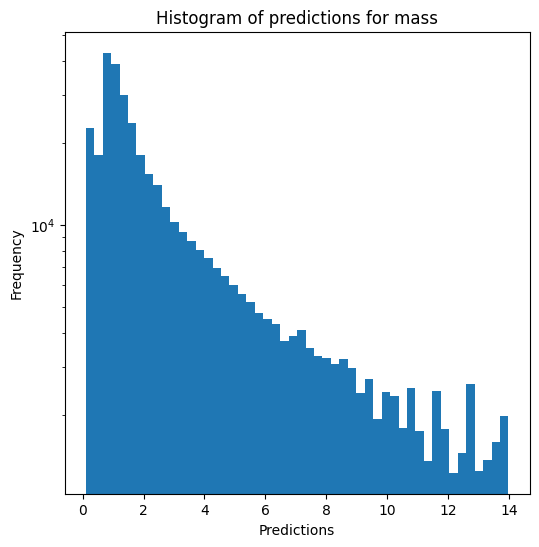

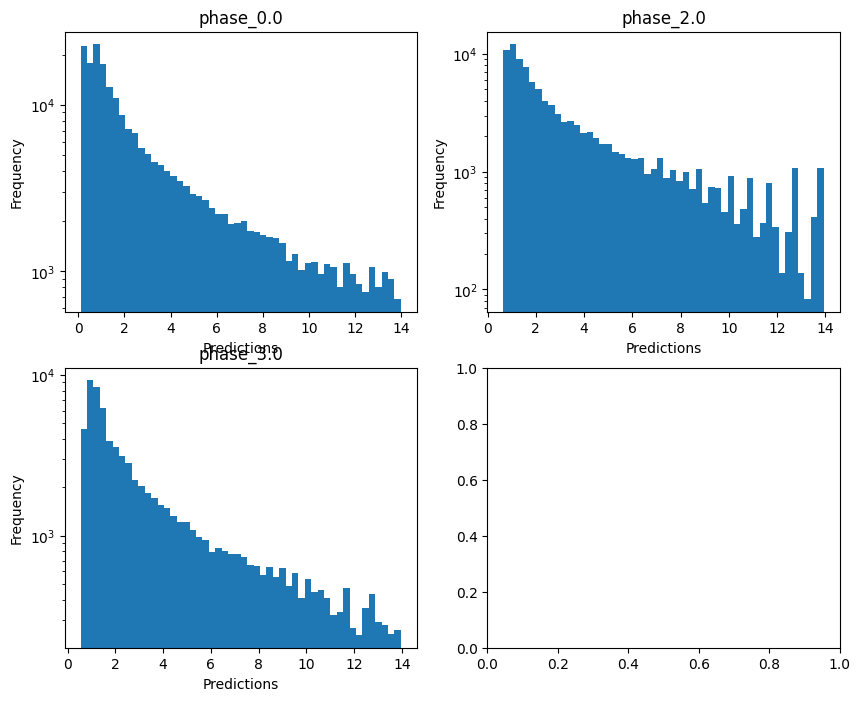


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9998866691072866
  RMSE :  0.004484731334307337
  MAE :  0.0029733293078907596
  MedAE :  0.0020297046142126463
  CORR :  0.9999436912544806
  MAX_ER :  0.05764616047952276
  Percentiles : 
    75th percentile :  0.0037668648258606108
    90th percentile :  0.006567917493276518
    95th percentile :  0.009109236786416945
    99th percentile :  0.016483777004184276

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9998636785851032
  RMSE :  0.005432489292342897
  MAE :  0.004123034785264384
  MedAE :  0.0032248505226852853
  CORR :  0.9999318926840819
  MAX_ER :  0.04238537207175552
  Percentiles : 
    75th percentile :  0.005585922956497791
    90th percentile :  0.008829797914458806
    95th percentile :  0.01113603943935649
    99th percentile :  0.01624944390648452

radius results 

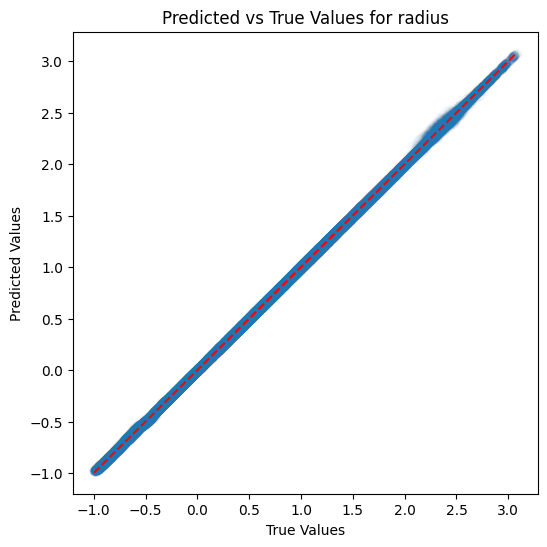

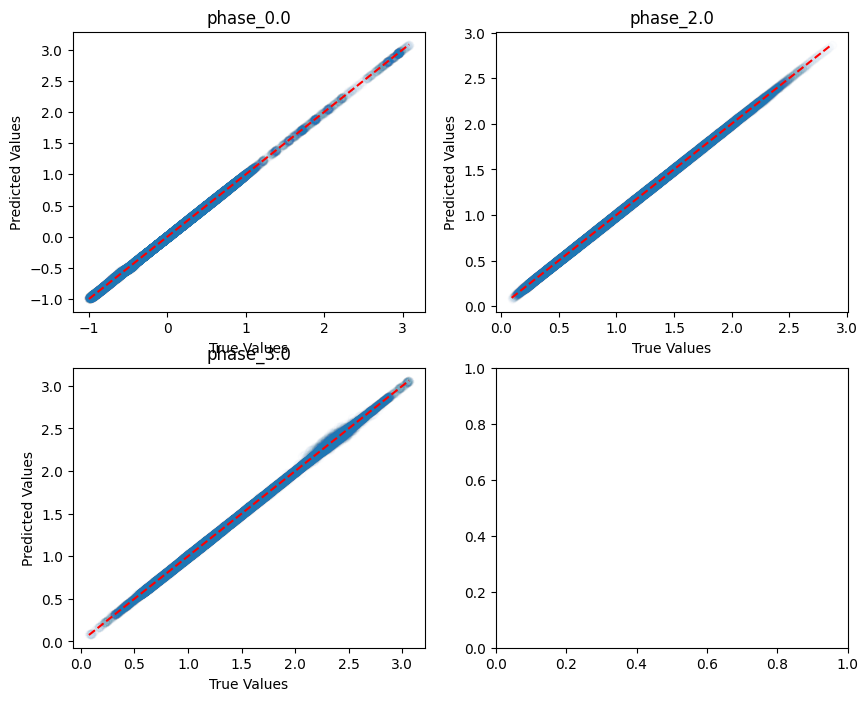

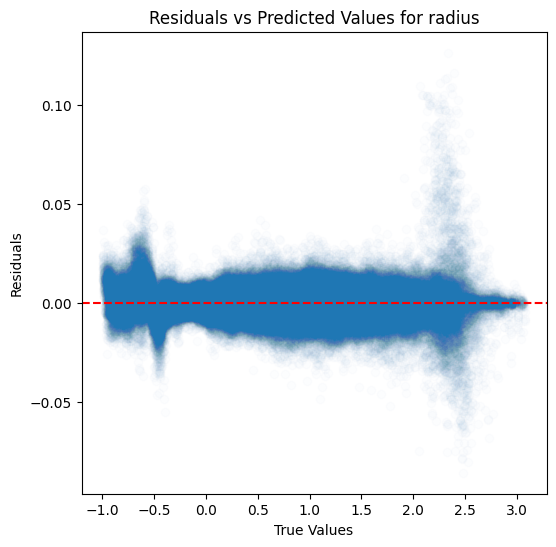

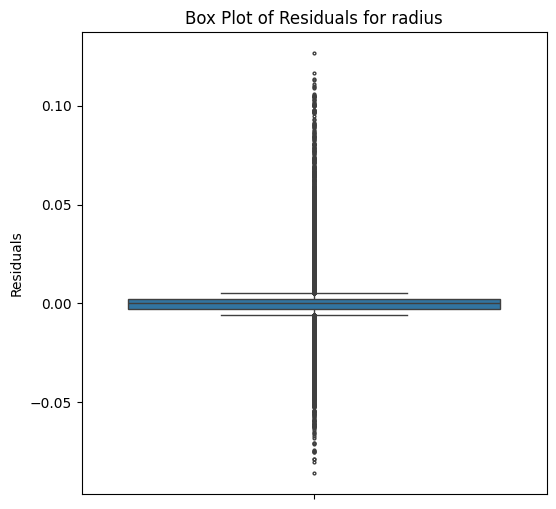

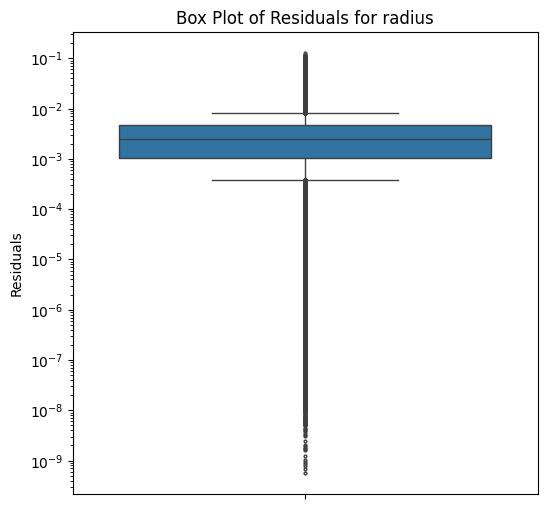

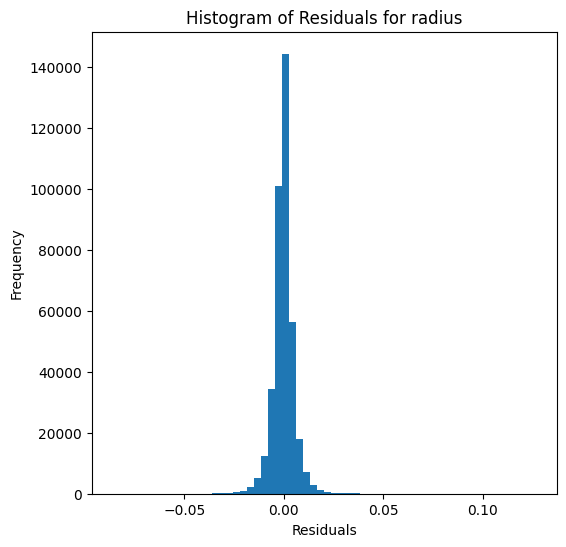

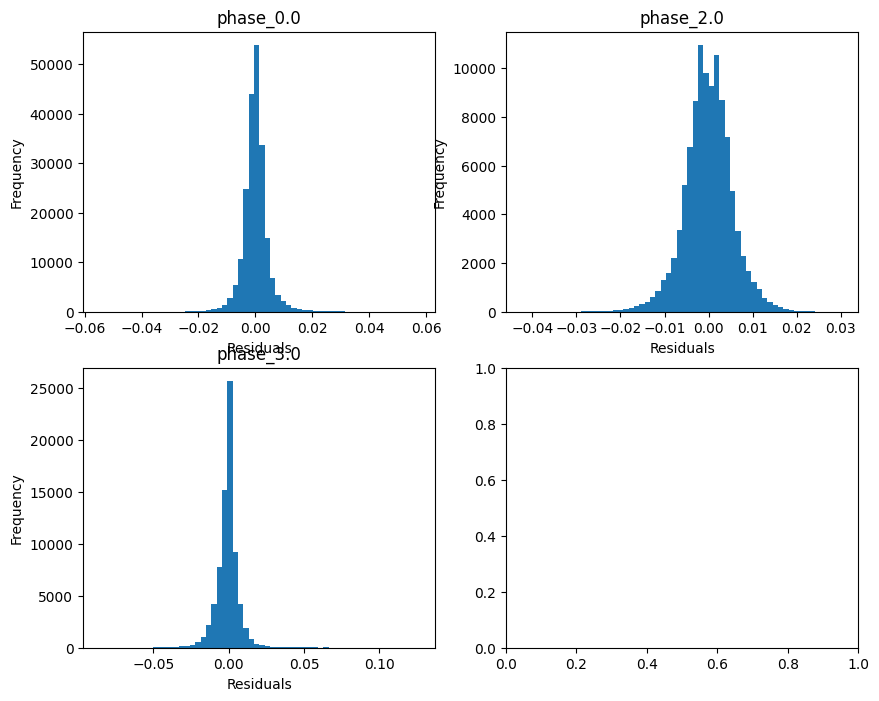

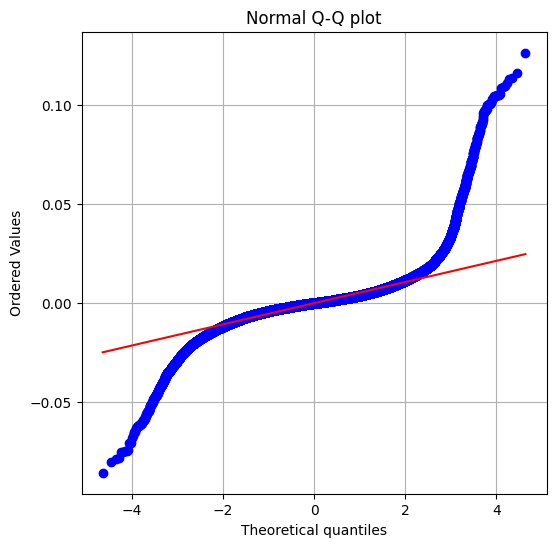

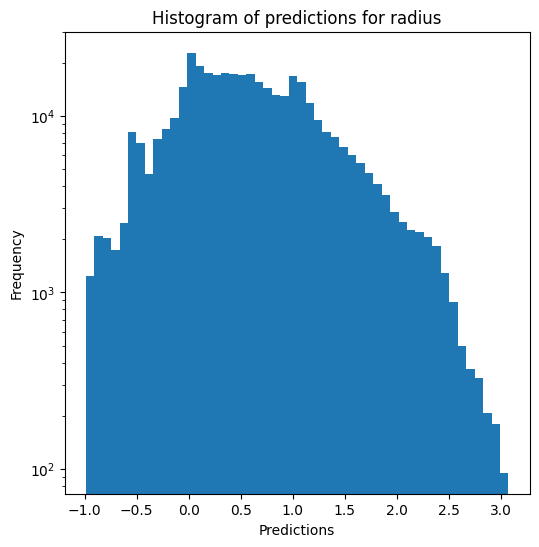

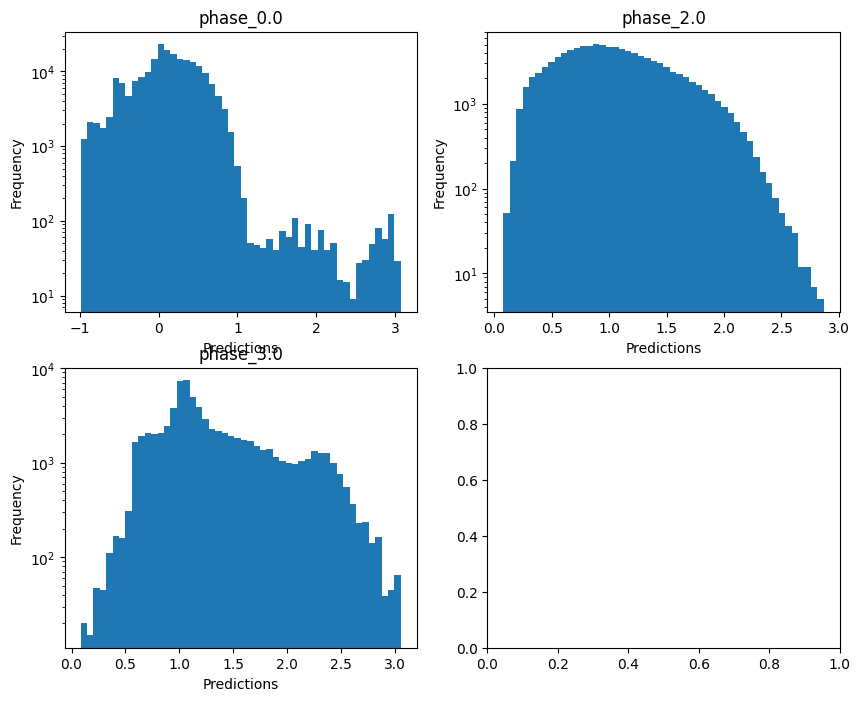

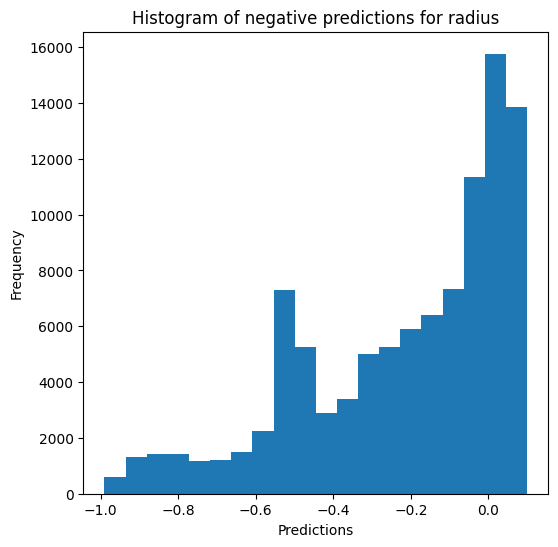

Saving predictions and results...


In [15]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9999228506201384
  RMSE :  0.02894630936887418
  MAE :  0.008814600032672362
  MedAE :  0.0024455564908577587
  CORR :  0.9999614369854419
  MAX_ER :  2.3224352312602594
  Percentiles : 
    75th percentile :  0.007139291819060034
    90th percentile :  0.019600496871808922
    95th percentile :  0.03502920752998333
    99th percentile :  0.10211569067472864

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999735152200081
  RMSE :  0.016811170172278782
  MAE :  0.008435936672566166
  MedAE :  0.0043399270813200275
  CORR :  0.9999869168352696
  MAX_ER :  0.545431831520073
  Percentiles : 
    75th percentile :  0.010110184788384852
    90th percentile :  0.01888814526499092
    95th

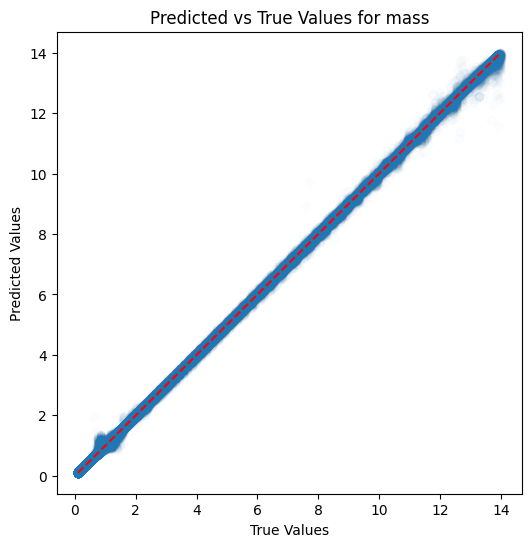

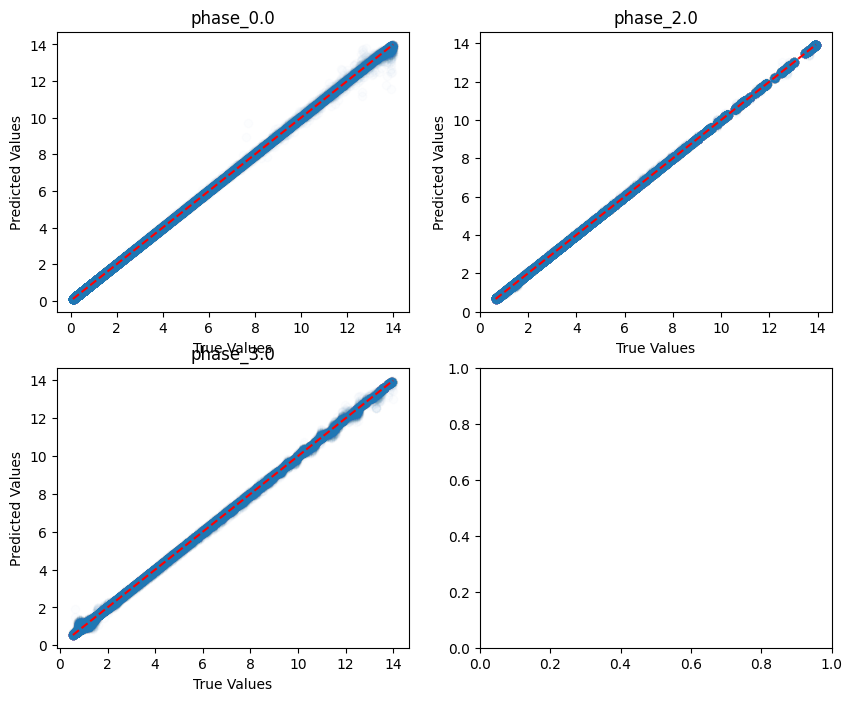

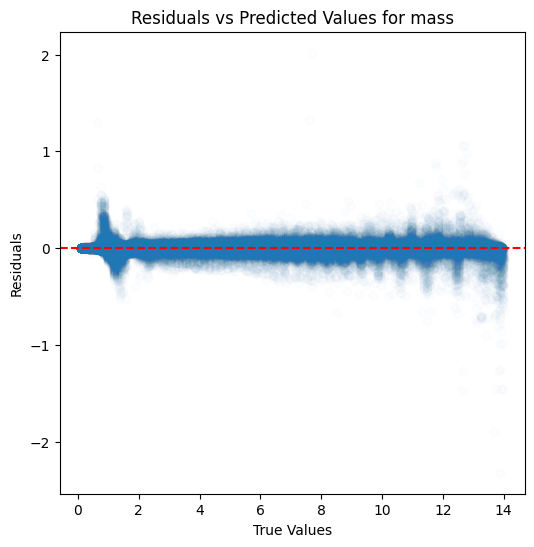

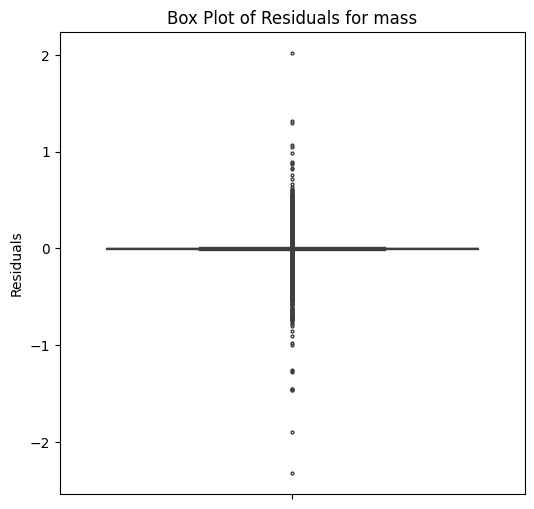

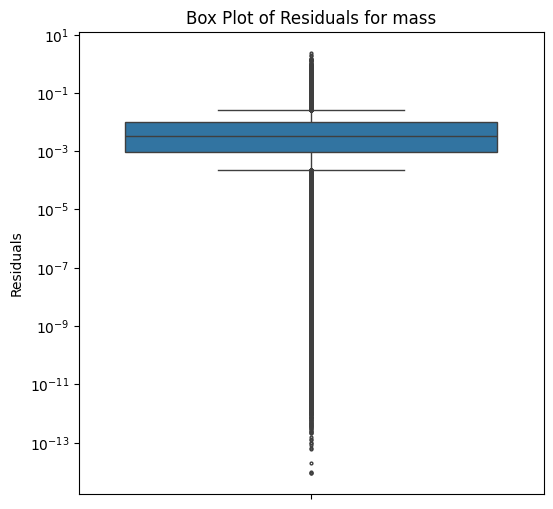

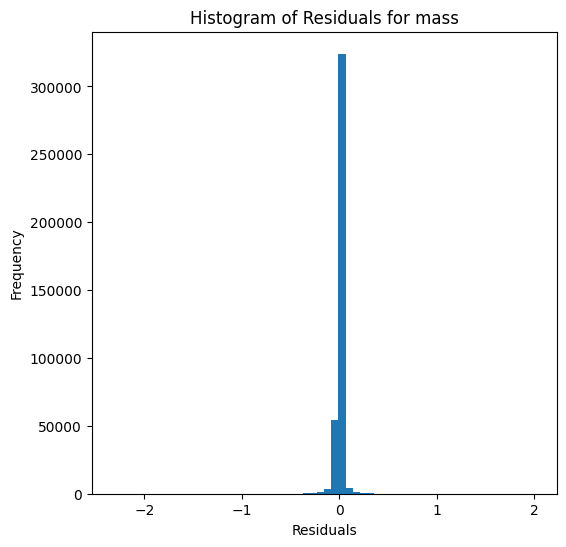

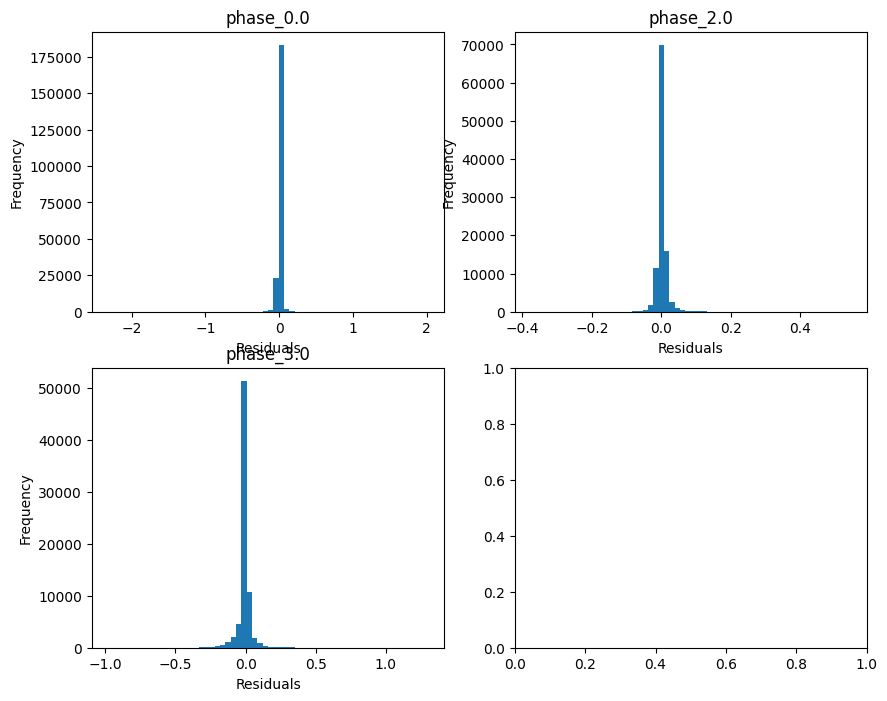

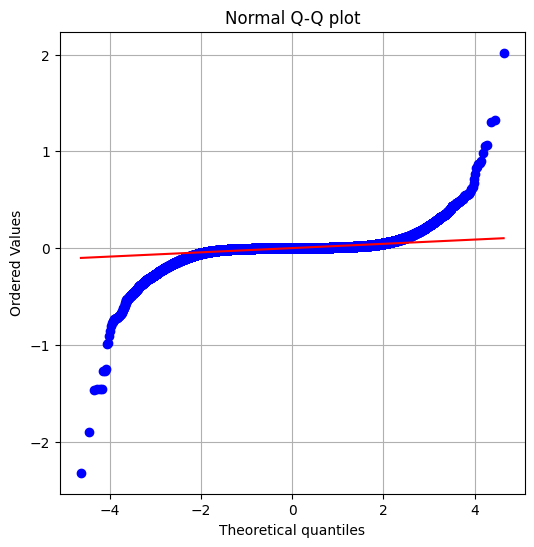

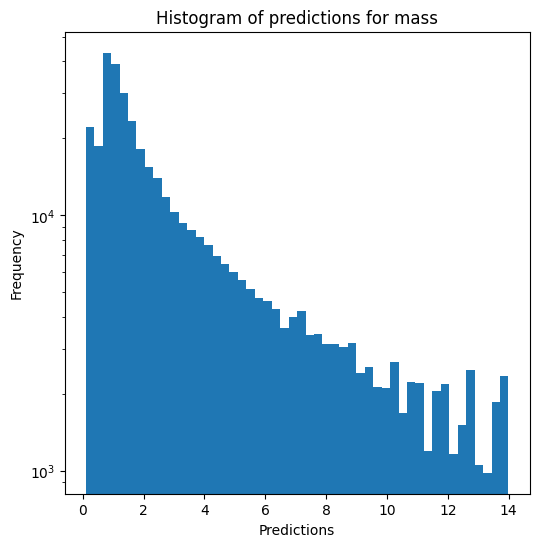

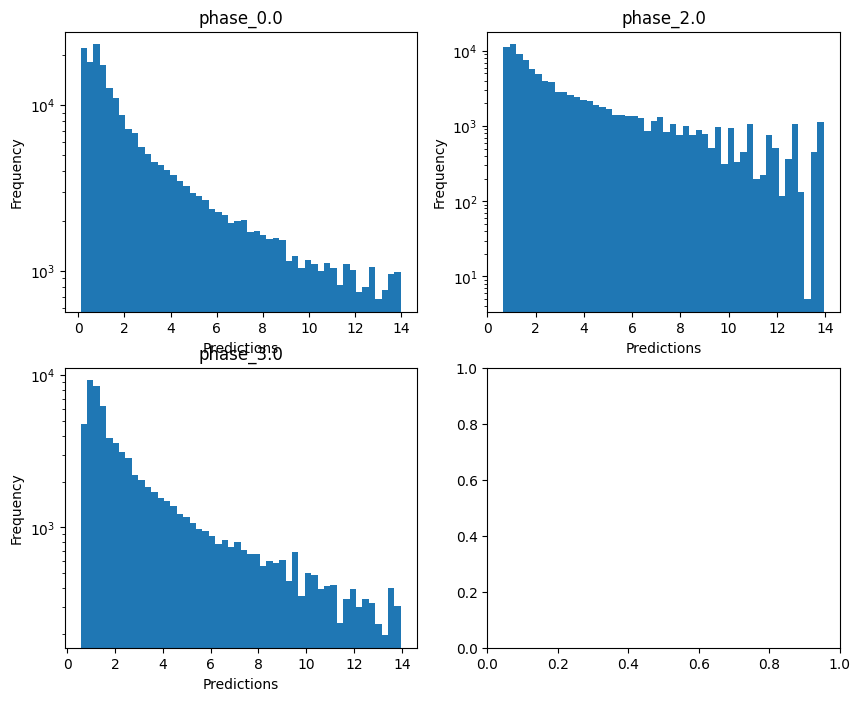

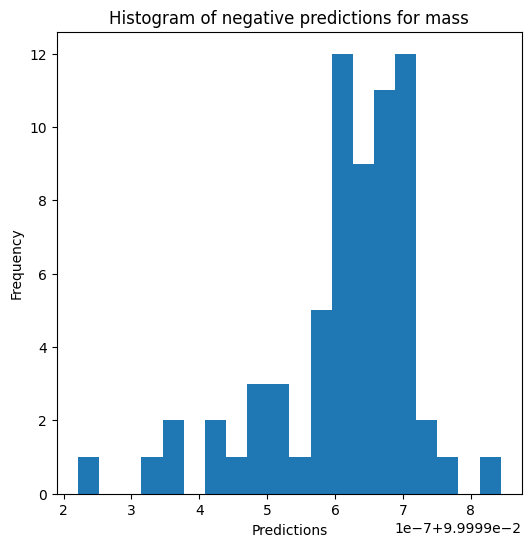


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9999531794588995
  RMSE :  0.0028866622709114356
  MAE :  0.0016275735601662602
  MedAE :  0.0008992201932891963
  CORR :  0.9999766081722201
  MAX_ER :  0.12662507337837514
  Percentiles : 
    75th percentile :  0.0019381159885571986
    90th percentile :  0.003778096421699414
    95th percentile :  0.005588981581365171
    99th percentile :  0.011353065589851644

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9999183093347295
  RMSE :  0.004252394466449448
  MAE :  0.0029234738303225106
  MedAE :  0.0020016252075732988
  CORR :  0.9999604709687924
  MAX_ER :  0.05793750576810952
  Percentiles : 
    75th percentile :  0.003933272459781645
    90th percentile :  0.00664144404420859
    95th percentile :  0.00880272970422311
    99th percentile :  0.014406408110640284

radius result

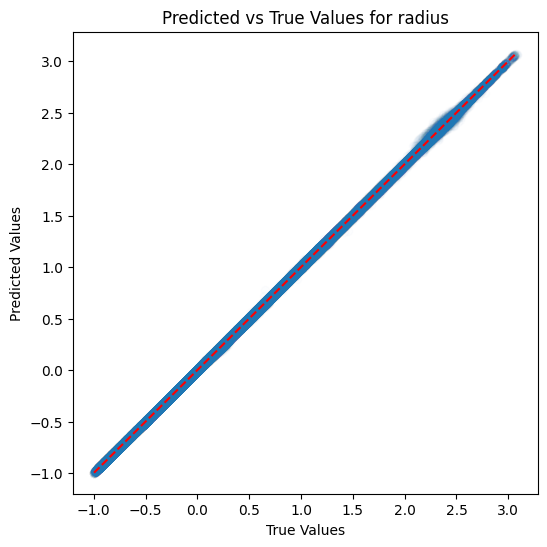

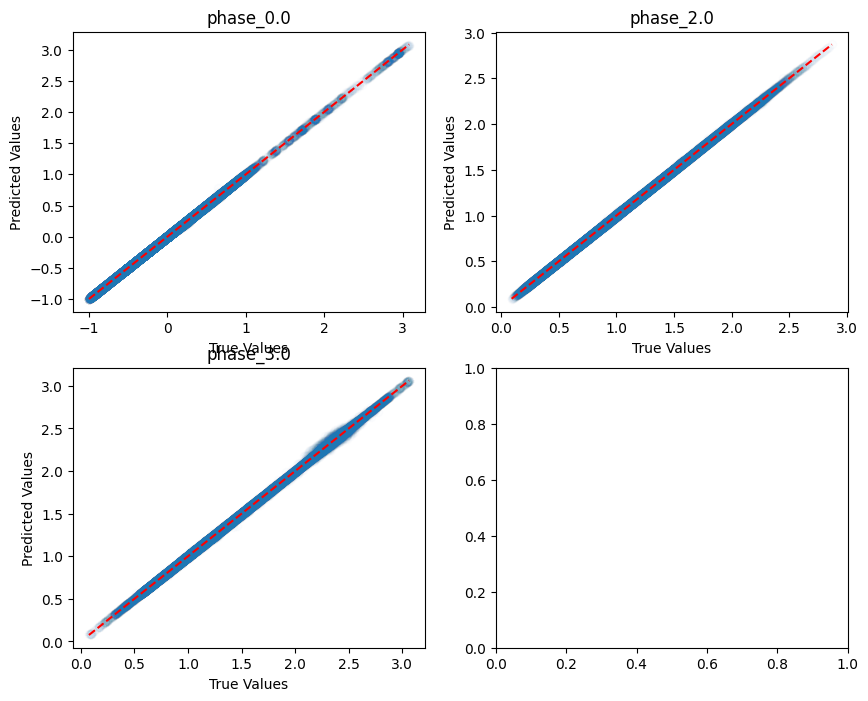

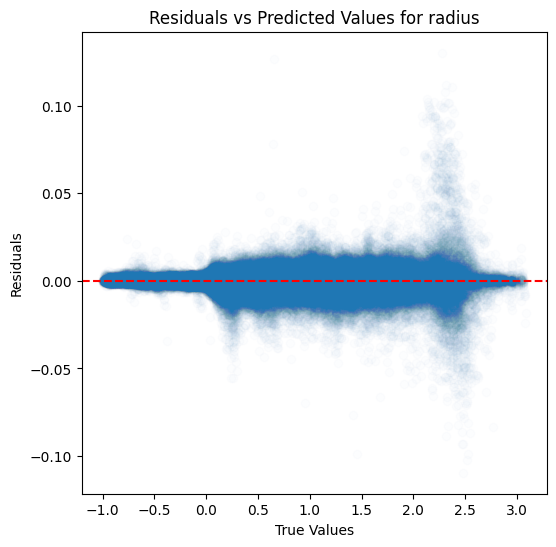

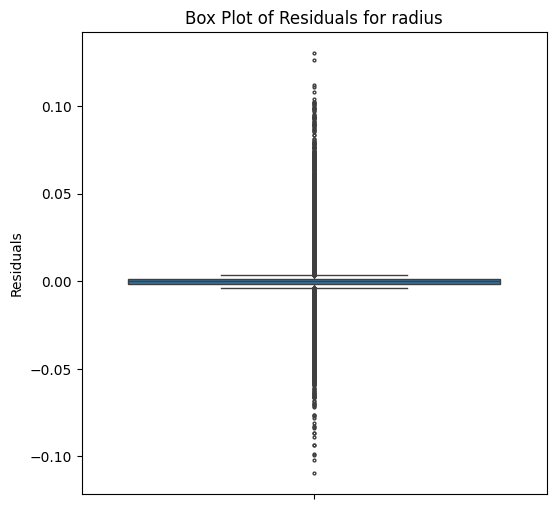

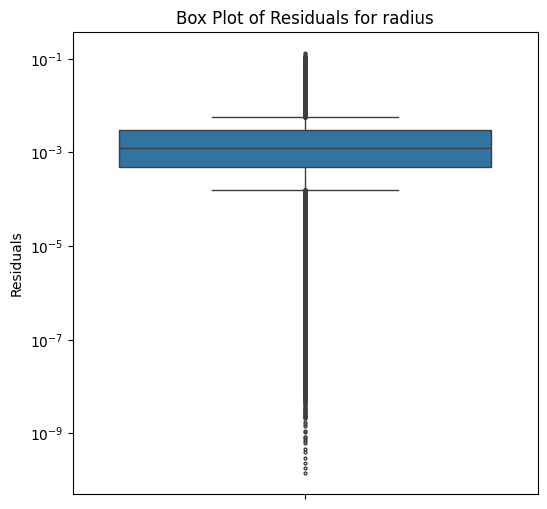

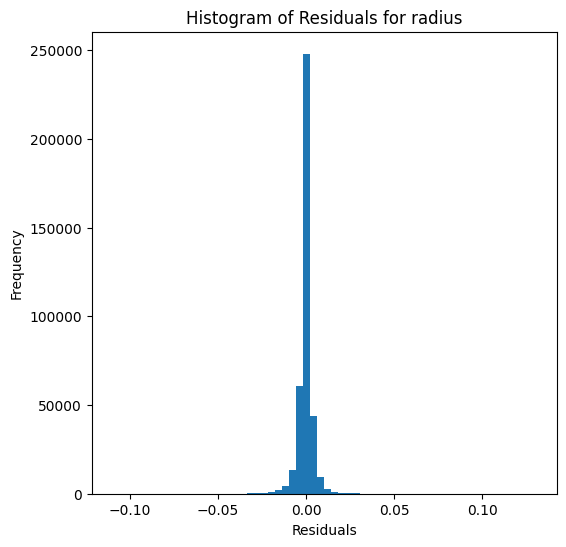

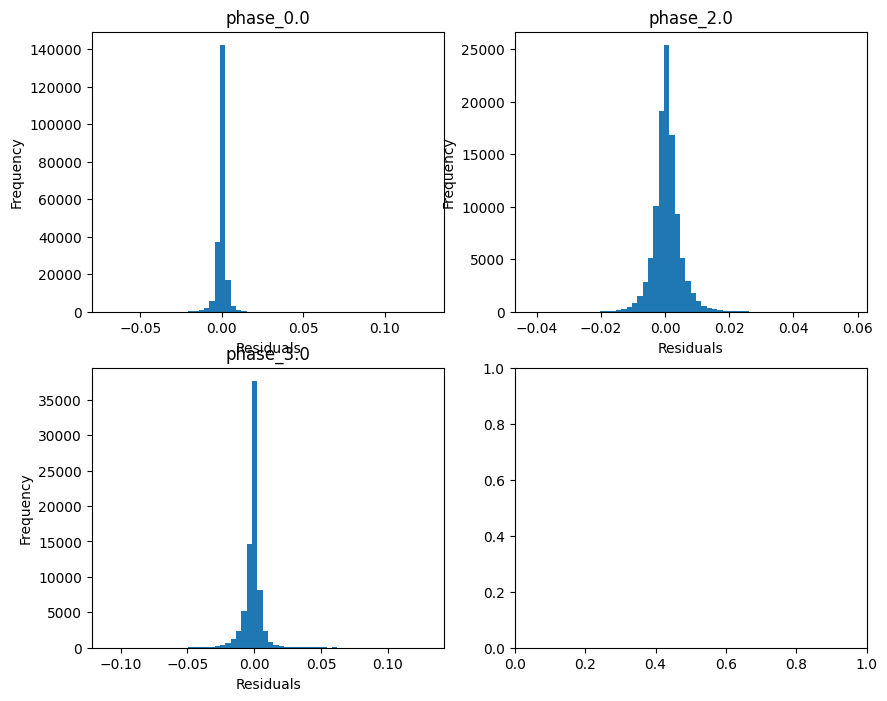

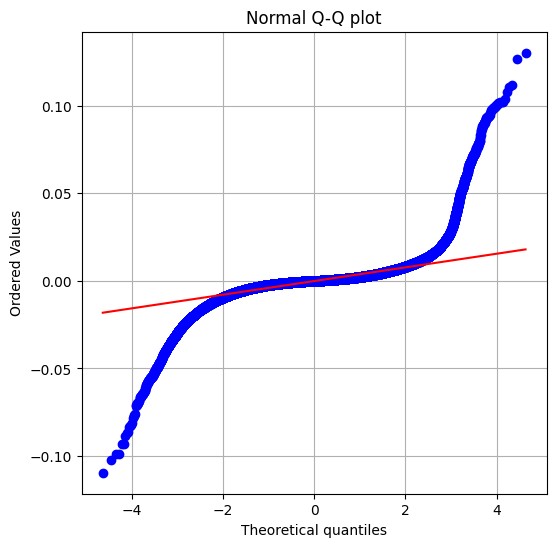

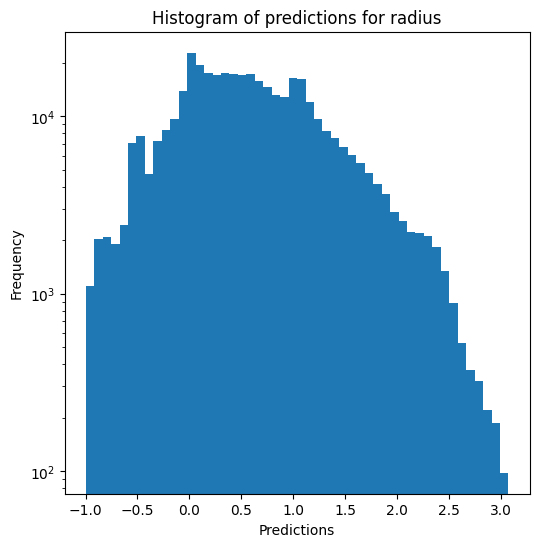

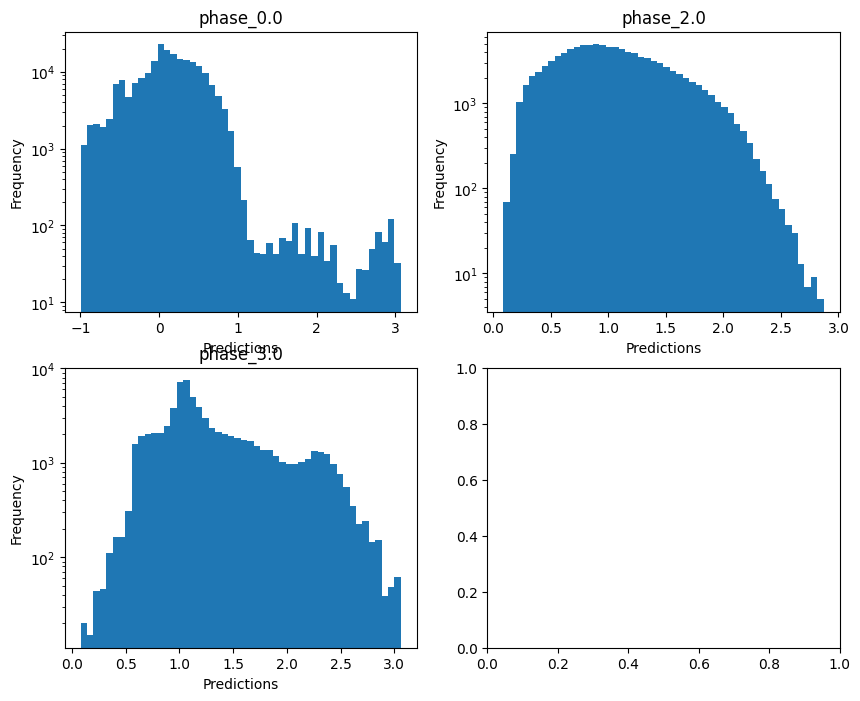

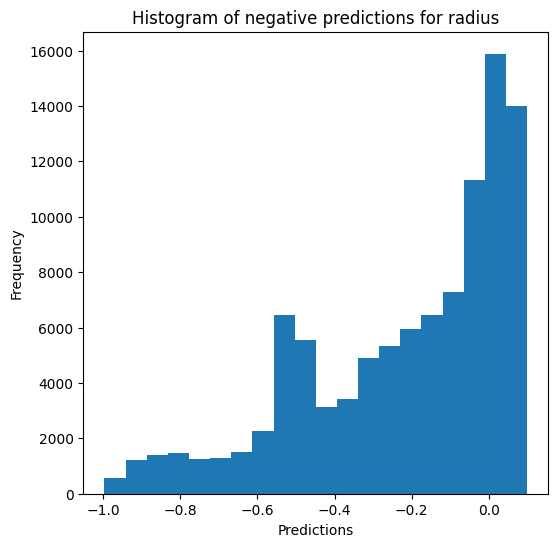

Saving predictions and results...


In [17]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [18]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9987913129092161
  RMSE :  0.11457360390233233
  MAE :  0.06424023521346028
  MedAE :  0.03191799259067918
  CORR :  0.9993955112248282
  MAX_ER :  2.518844127047103
  Percentiles : 
    75th percentile :  0.07767657402584005
    90th percentile :  0.1573238204868826
    95th percentile :  0.23131138864914608
    99th percentile :  0.4545480900205863

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997571012305564
  RMSE :  0.052514751302890204
  MAE :  0.03594215238530267
  MedAE :  0.02338170592910005
  CORR :  0.9998844253979222
  MAX_ER :  0.642151193964617
  Percentiles : 
    75th percentile :  0.04850271821692931
    90th percentile :  0.0837132191110273
    95th percentile :

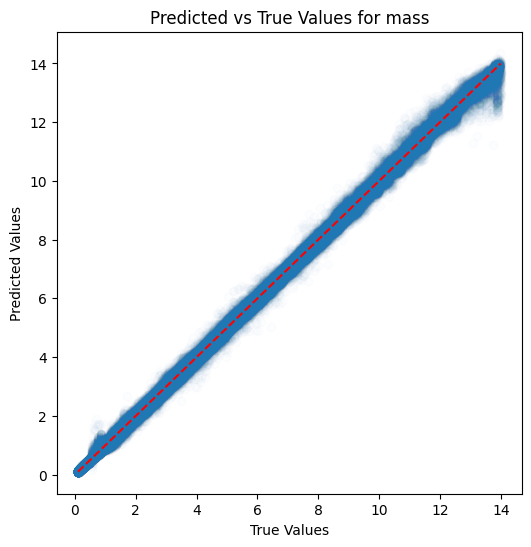

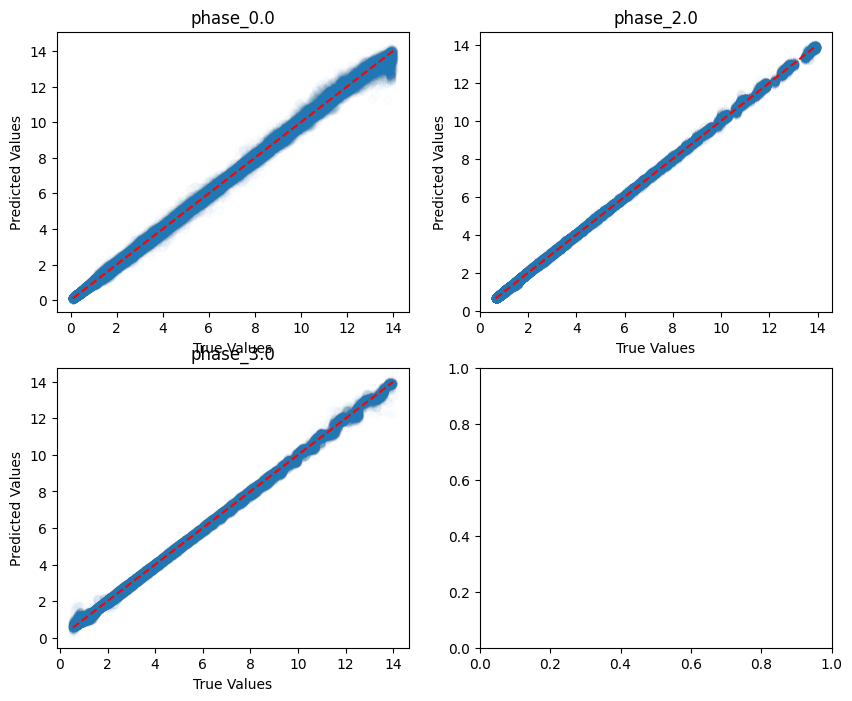

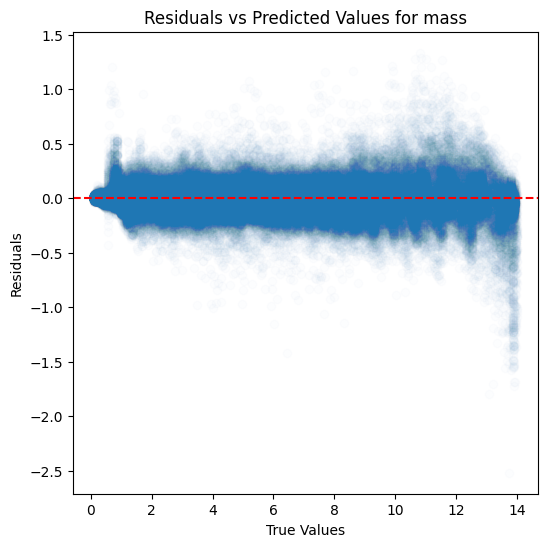

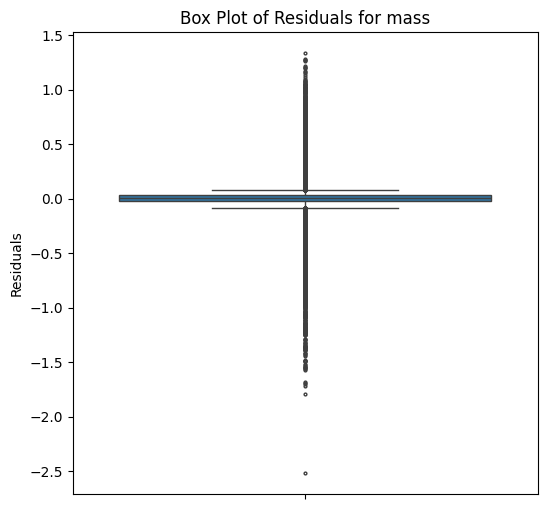

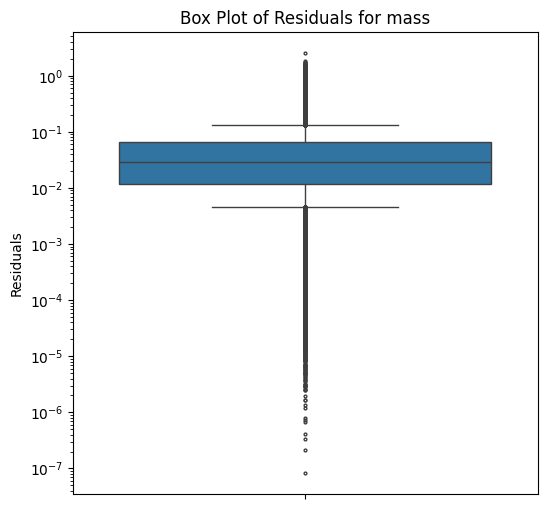

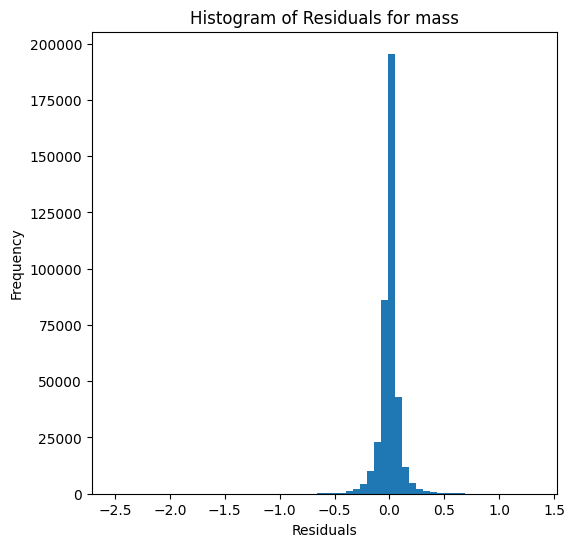

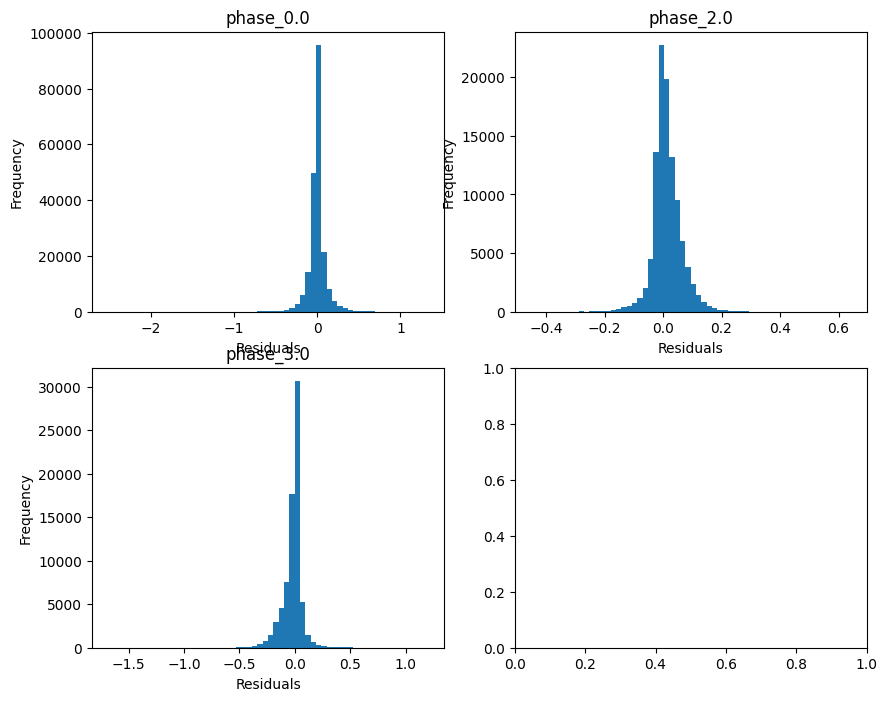

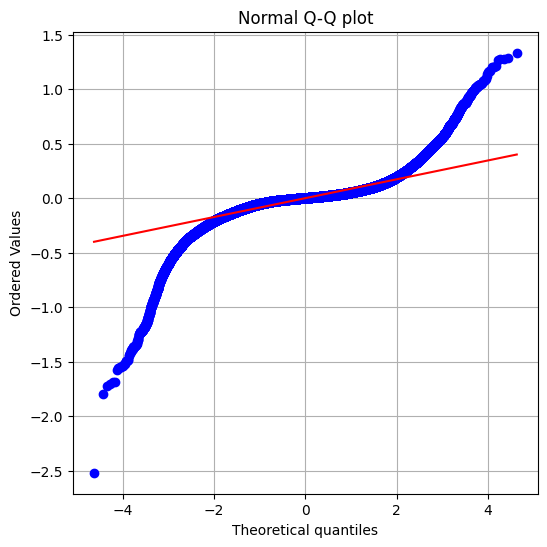

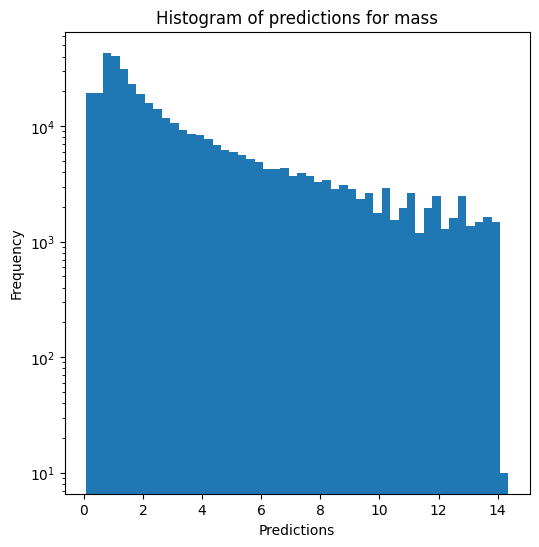

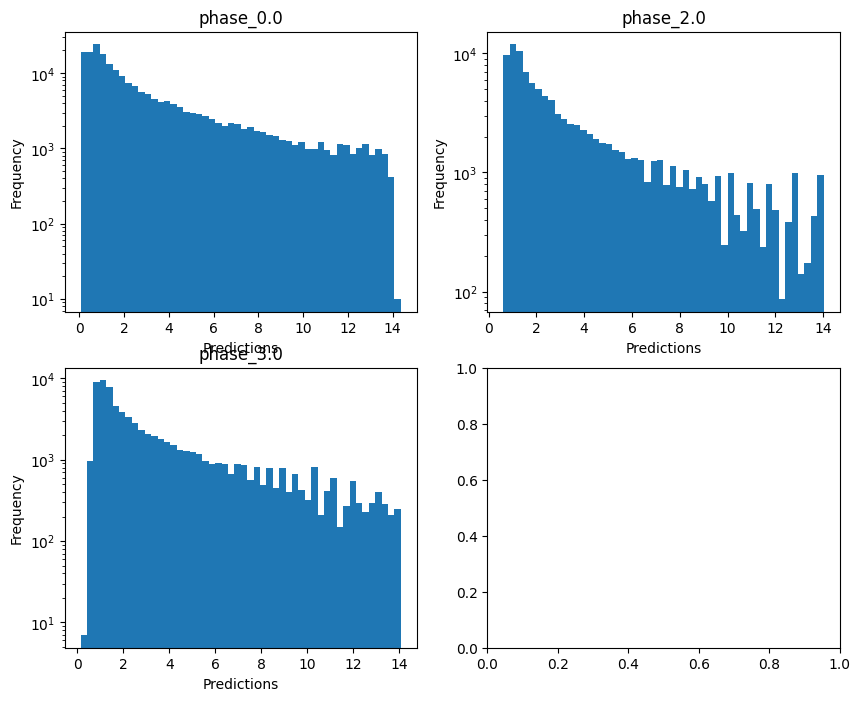

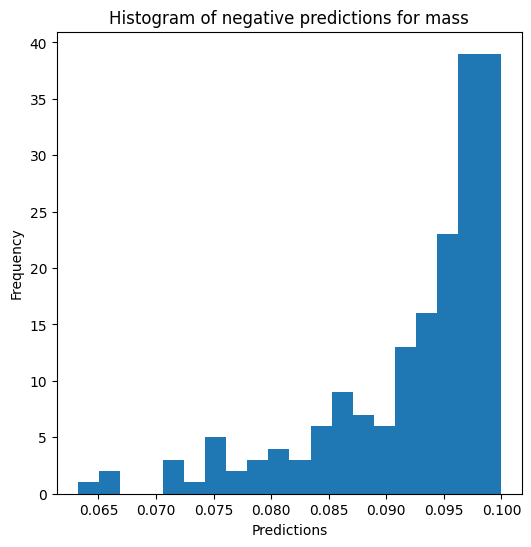


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9995125882012242
  RMSE :  0.00930069381977632
  MAE :  0.007073977245373418
  MedAE :  0.005535151961012397
  CORR :  0.9997562945603362
  MAX_ER :  0.05543917187310028
  Percentiles : 
    75th percentile :  0.009911080440025088
    90th percentile :  0.015168085502214693
    95th percentile :  0.019033664736268177
    99th percentile :  0.027331626665973868

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9994165903788762
  RMSE :  0.01127886066489152
  MAE :  0.008758255983491541
  MedAE :  0.007099695898437092
  CORR :  0.999708515470801
  MAX_ER :  0.07215358738178246
  Percentiles : 
    75th percentile :  0.012438628337110624
    90th percentile :  0.01843410279951962
    95th percentile :  0.022590322107031
    99th percentile :  0.031484553612411086

radius results for the p

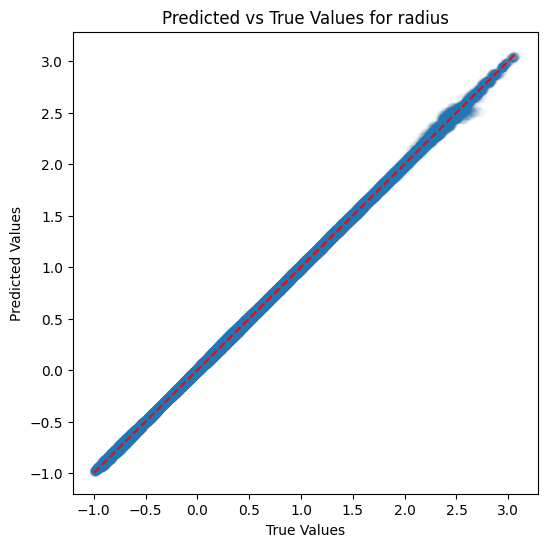

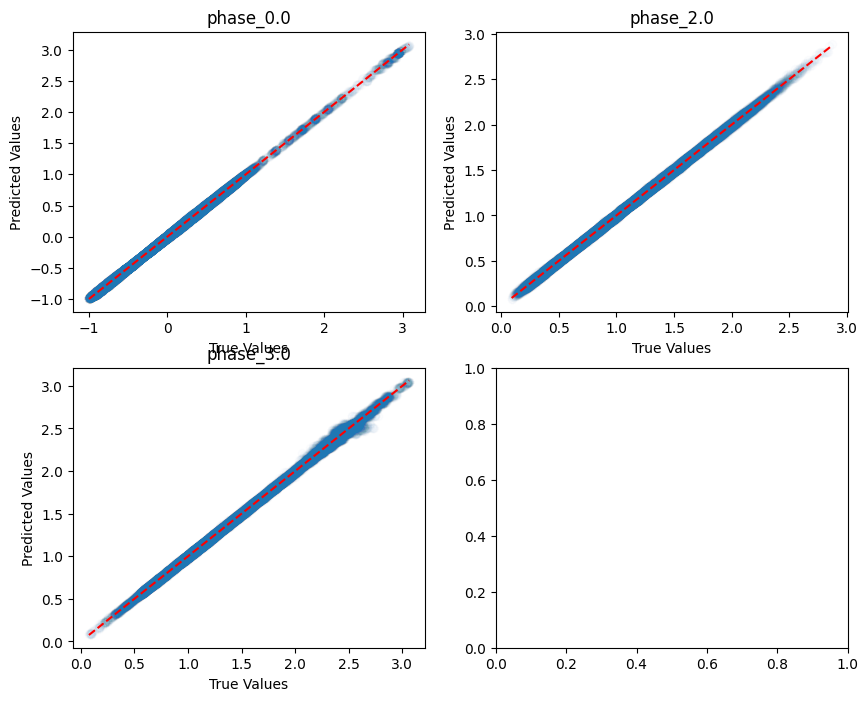

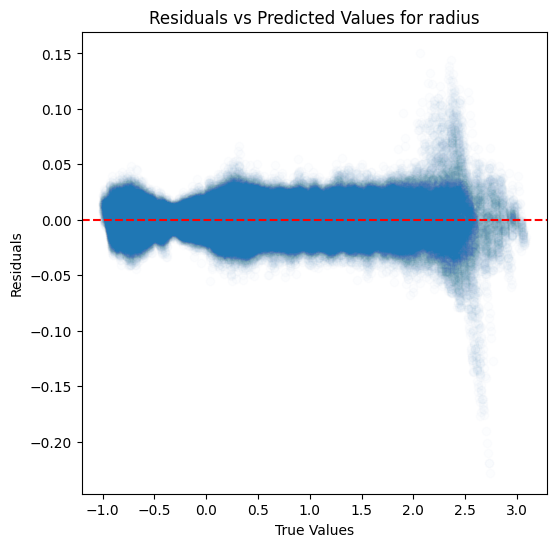

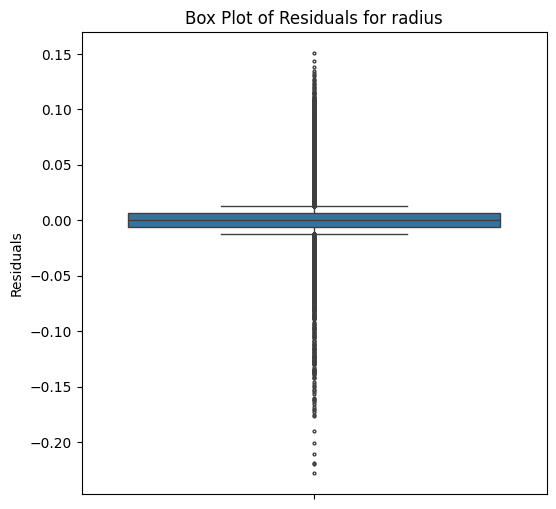

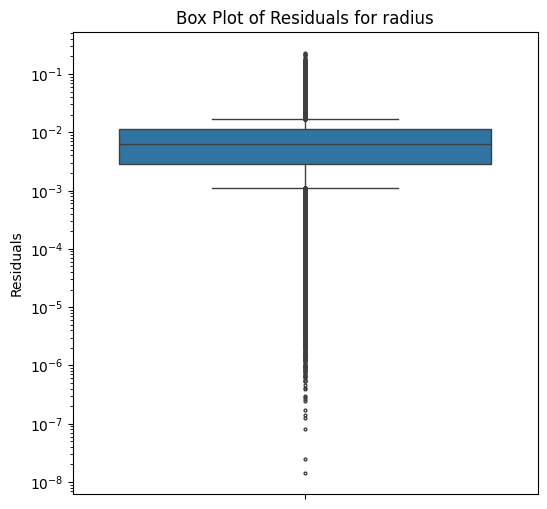

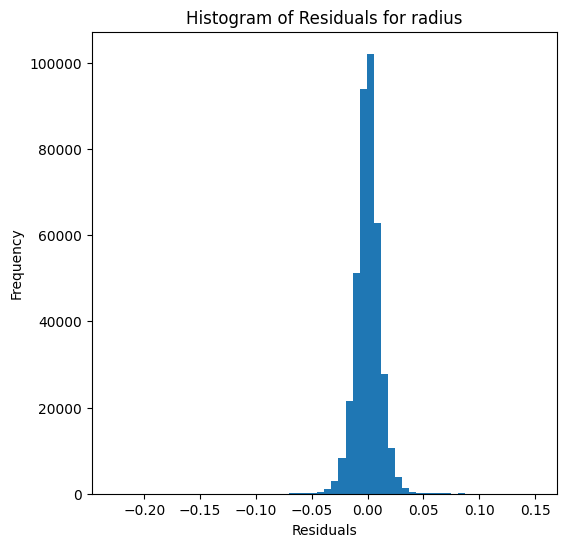

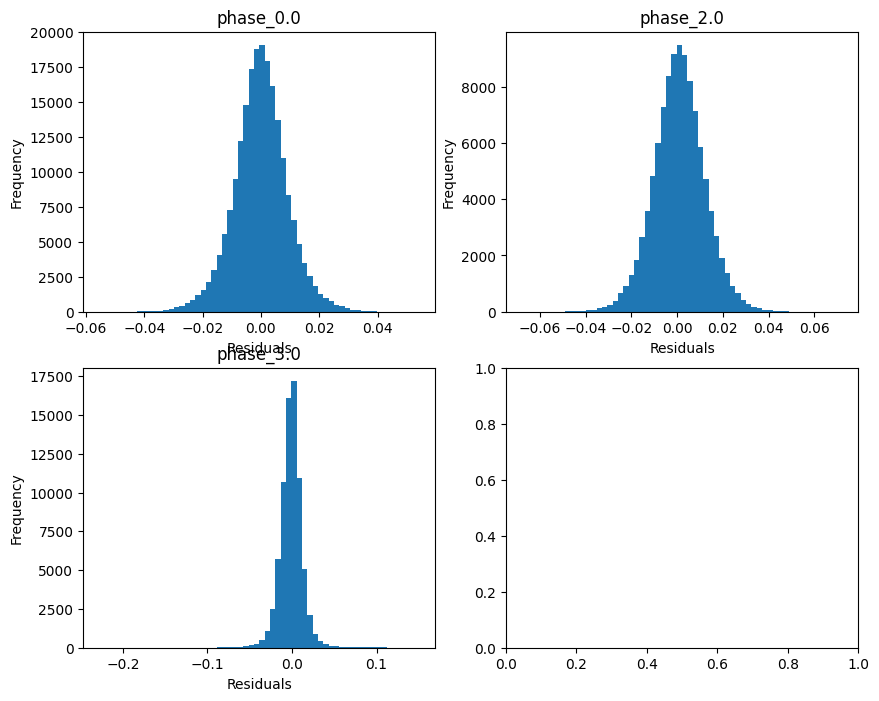

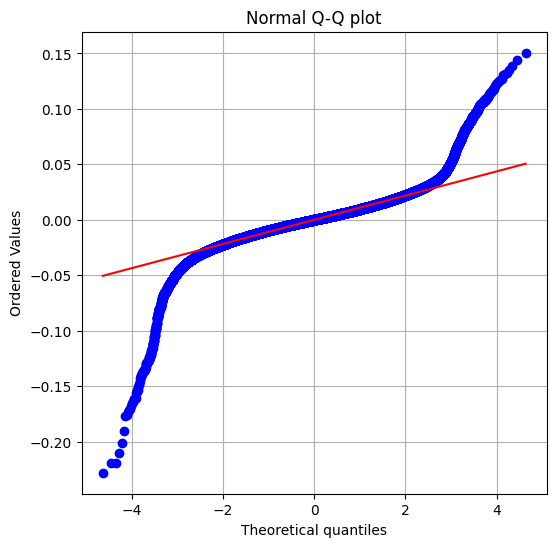

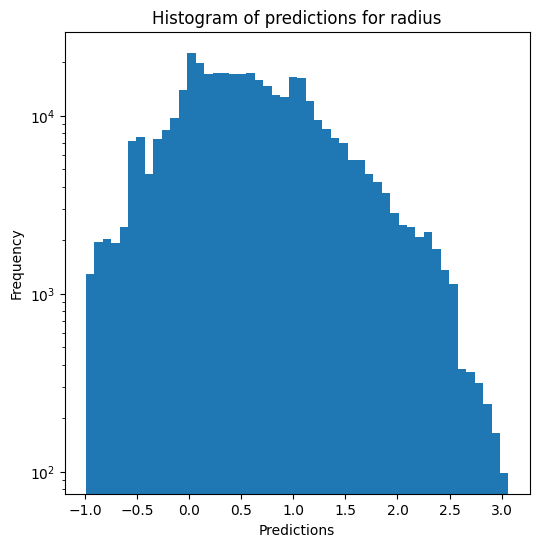

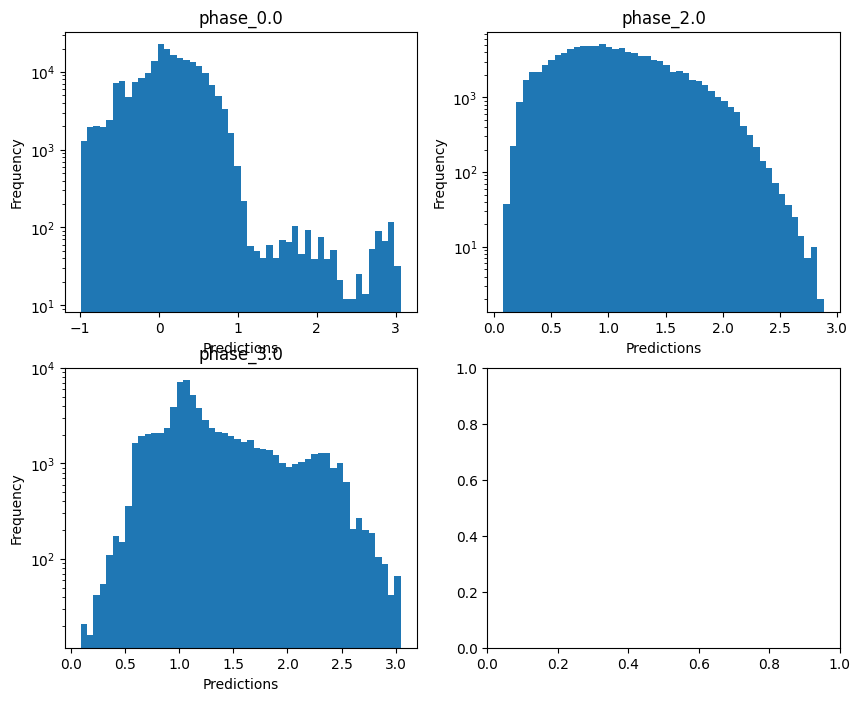

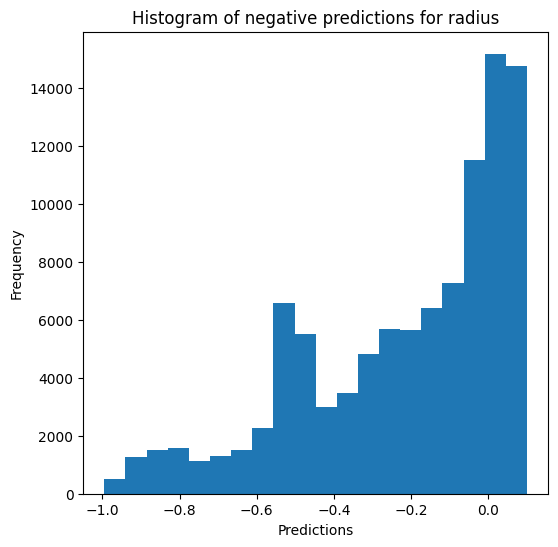

Saving predictions and results...


In [19]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [20]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard_14 train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.001427328045225864
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0012371866057135676
3 

...

0.0010837043396723029
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0012696497811536147
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0010919396102583492

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9996938380345541
  RMSE :  0.05779735395241246
  MAE :  0.026862492101210257
  MedAE :  0.015014642967404956
  CORR :  0.9998475939752604
  MAX_ER :  2.0179571576070607
  Percentiles : 
    75th percentile :  0.02835104827540169
    90th percentile :  0.05413213504035239
    95th percentile :  0.08511948186884005
    99th percentile :  0.22301952333847952

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997862339373257
  RMSE :  0.04805398954824669
  MAE :  0.029180794161728807
  MedAE :  0.019269448462182037
  CORR :  0.9998938886544968
  MAX_ER :  0.9434132440678127
  Percentiles : 
    75th percentile :  0.03636624033932556
    90th percentile :  0.06165839029405129
    95th percentile :  0.0868535827024777
    99th percentile :  0.1826

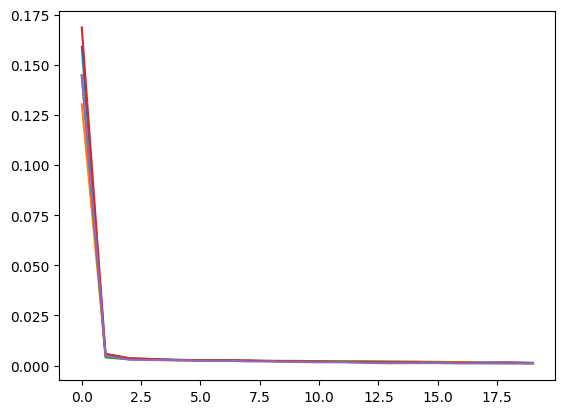

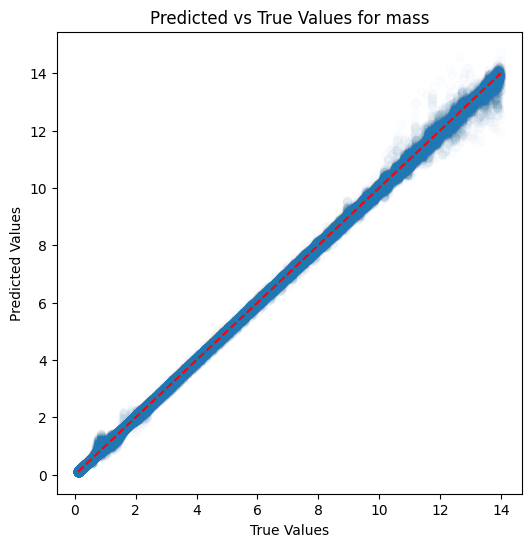

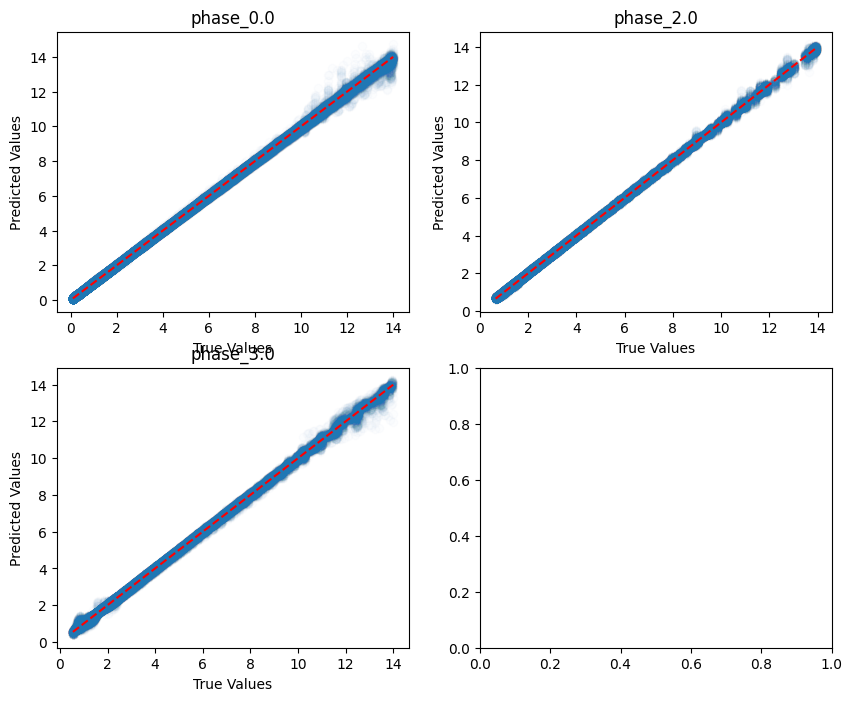

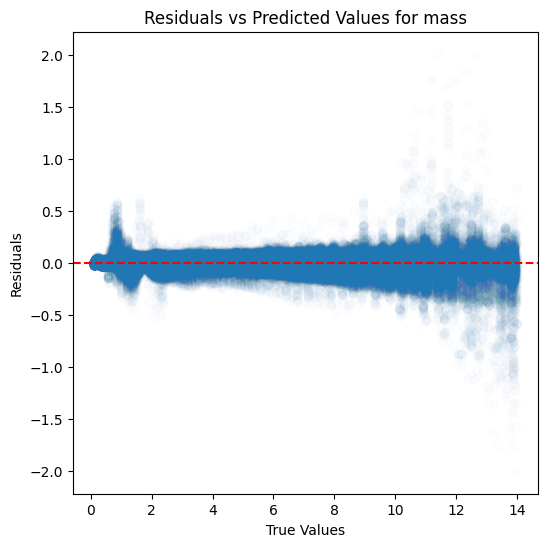

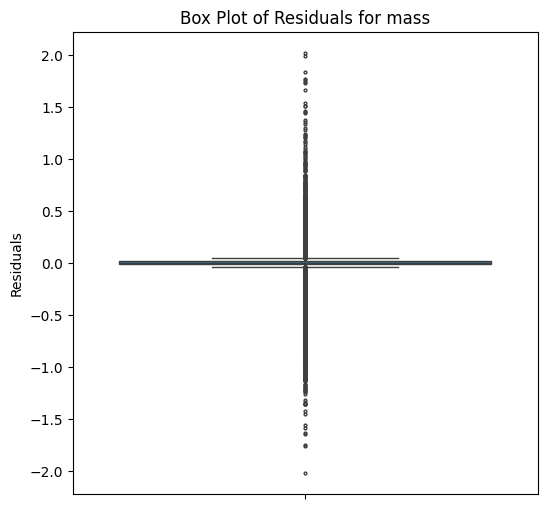

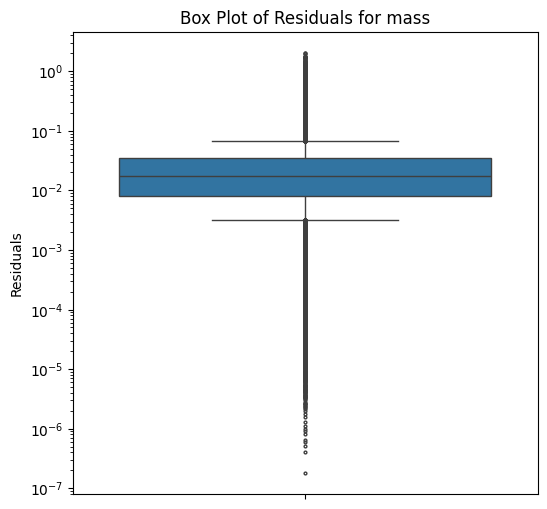

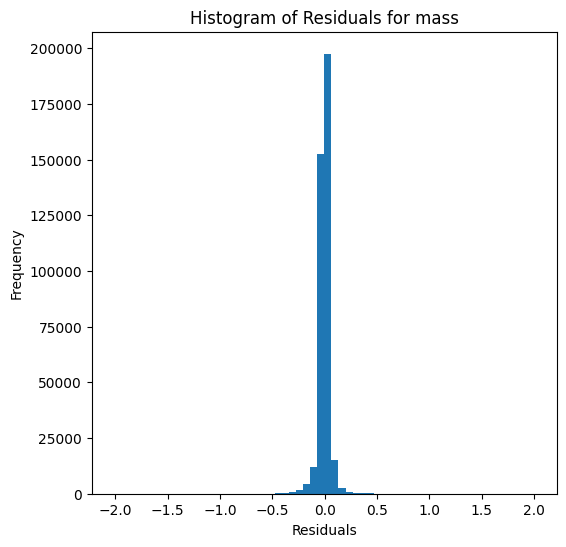

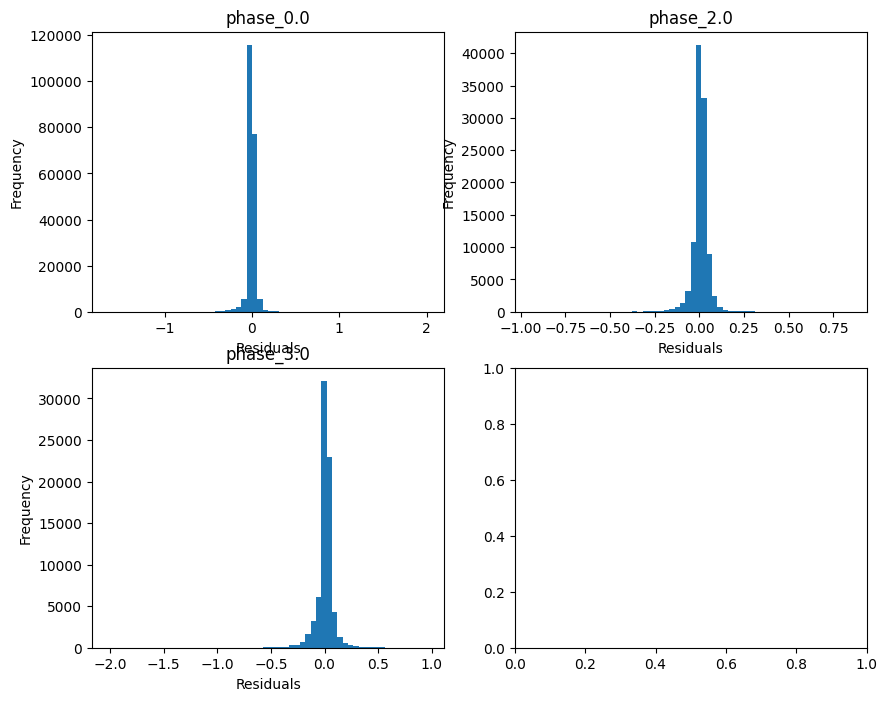

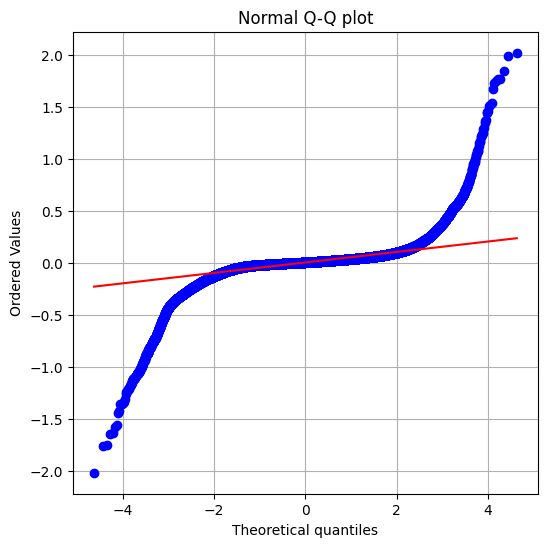

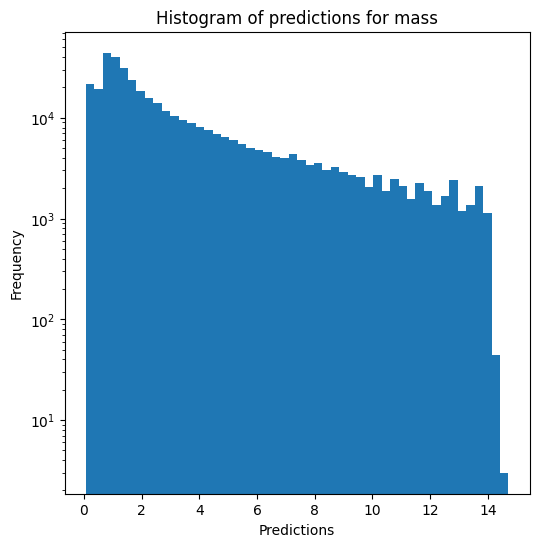

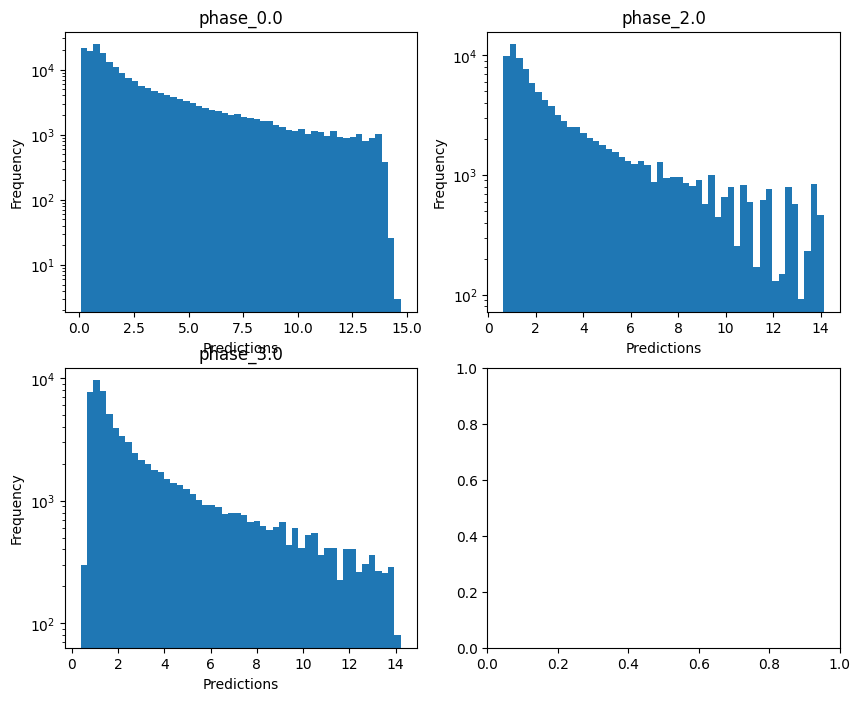

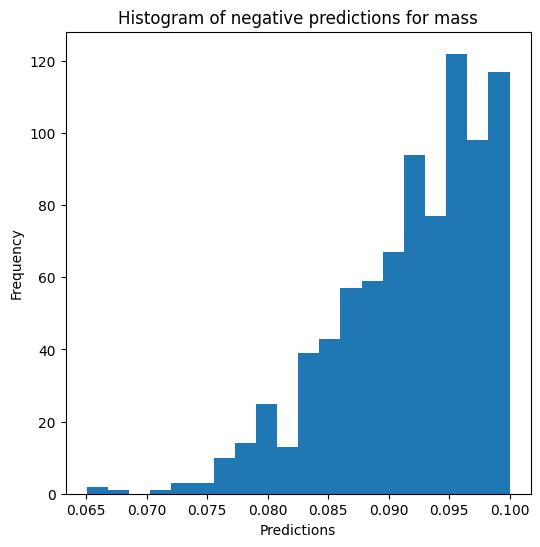


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.999422871432203
  RMSE :  0.010214389018457606
  MAE :  0.007984356267377321
  MedAE :  0.006621768886708401
  CORR :  0.9997270467152838
  MAX_ER :  0.06935740902088039
  Percentiles : 
    75th percentile :  0.011236699952856366
    90th percentile :  0.016394330418092615
    95th percentile :  0.019921357143318573
    99th percentile :  0.028613164733345017

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9994431814130673
  RMSE :  0.010979469020682062
  MAE :  0.00859392521244606
  MedAE :  0.007077591835632058
  CORR :  0.9997227473765712
  MAX_ER :  0.06323906475221808
  Percentiles : 
    75th percentile :  0.012183590391461496
    90th percentile :  0.017880307197869864
    95th percentile :  0.021950635380746857
    99th percentile :  0.03029270736092293

radius results for t

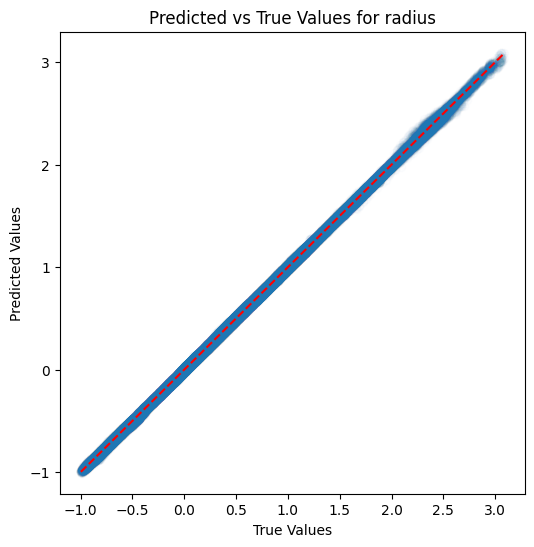

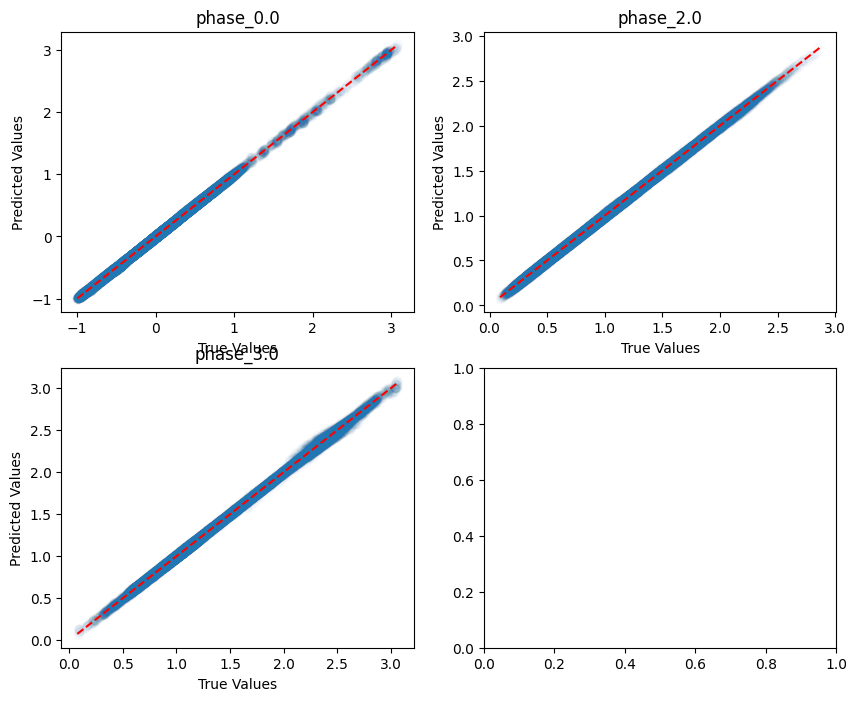

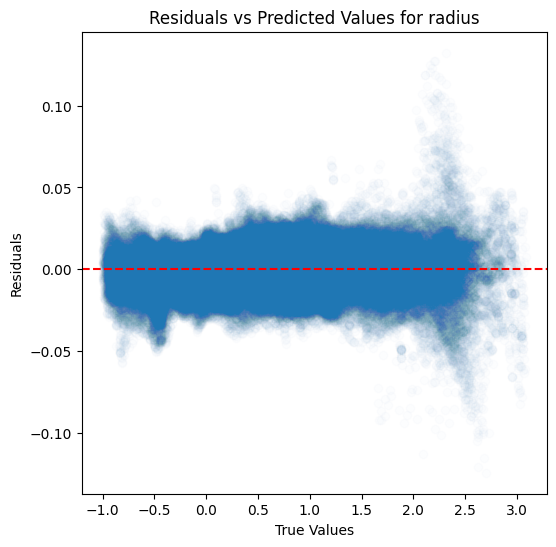

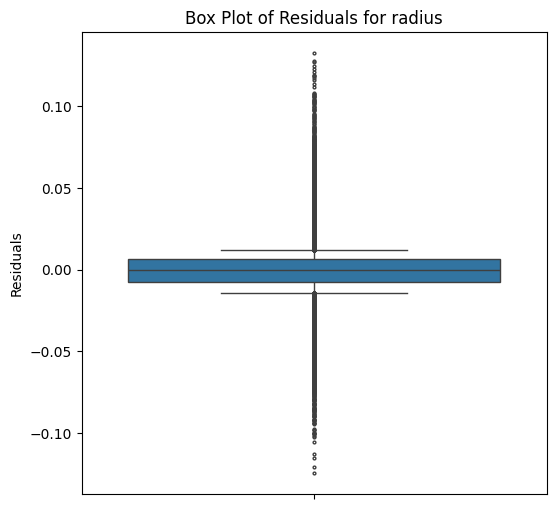

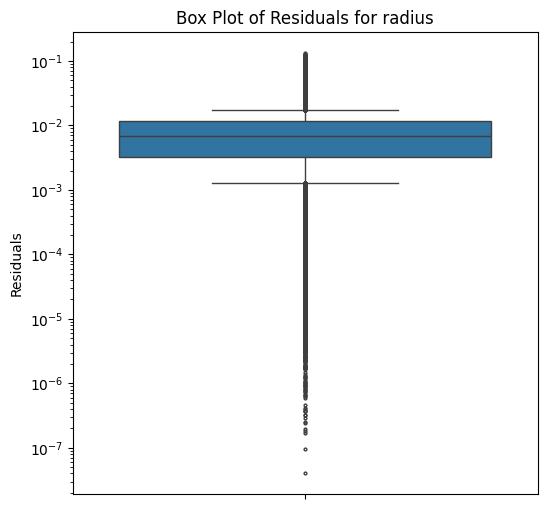

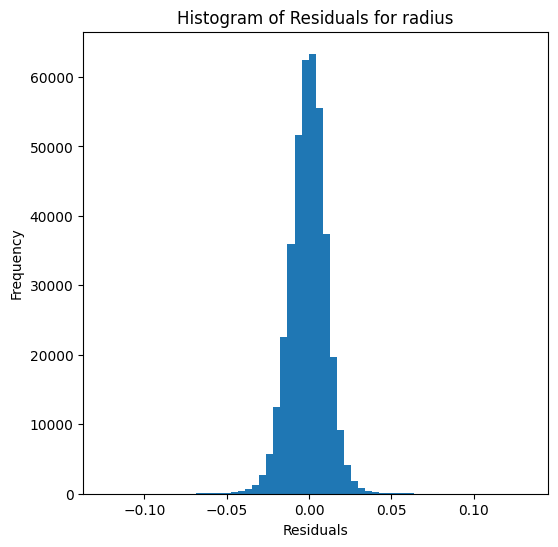

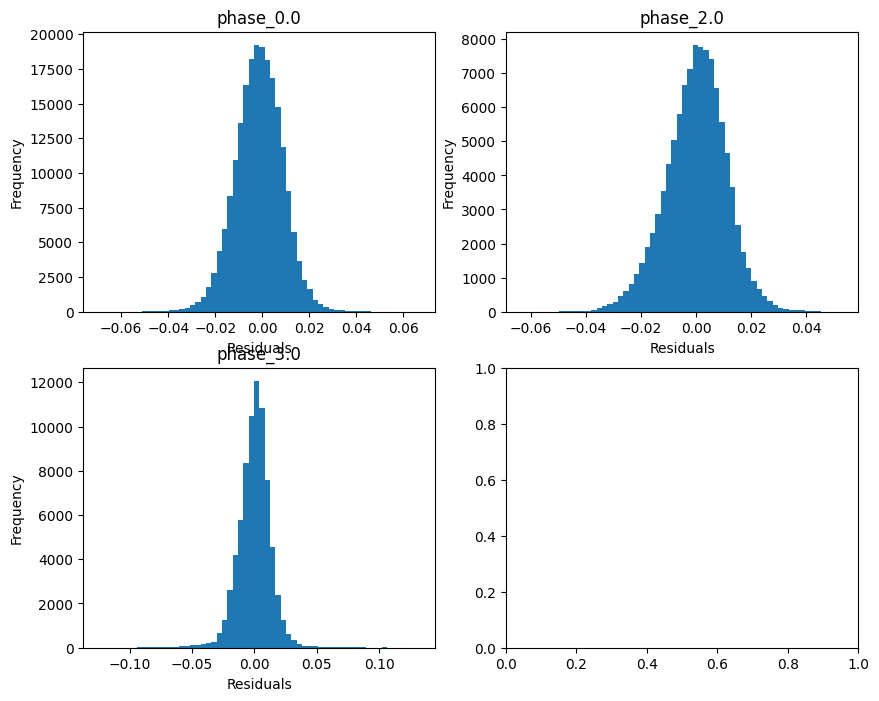

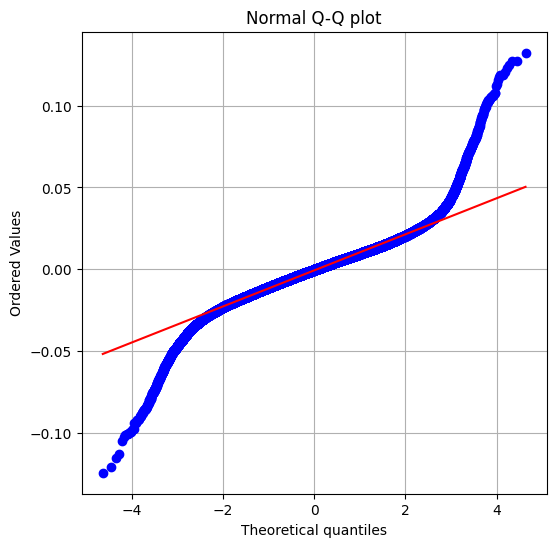

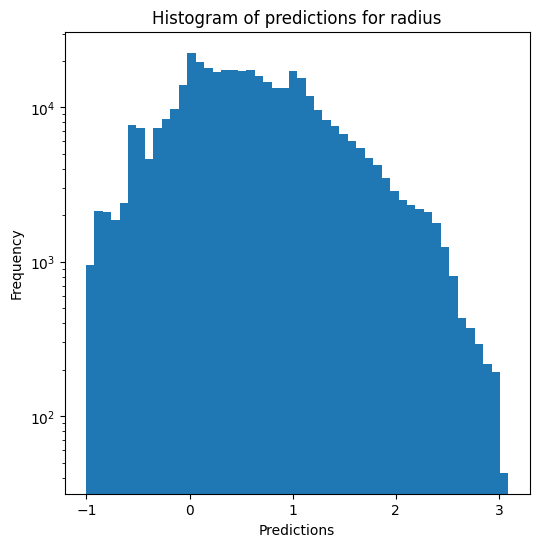

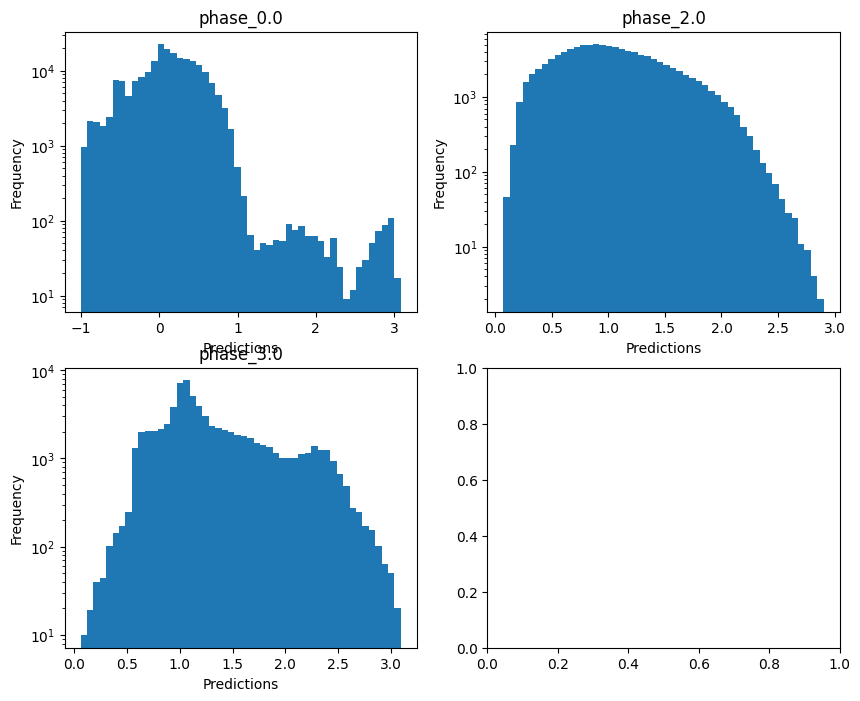

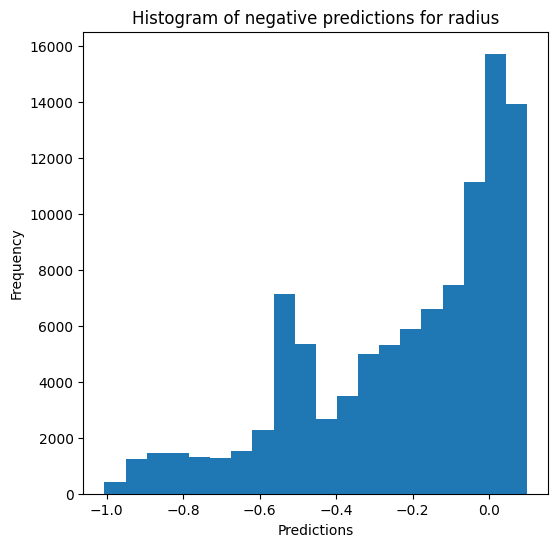

Saving predictions and results...


In [21]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, scaler_name=scaler_name, show=show,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon